# Table of Contents 

* [Data Loading and Imports](#data-loading-and-imports)
* [Data Pre-Processing](#data-preprocessing)
    * [Data Collection](#data-collection)
    * [Data Merge](#data-merge)
* [Exploratory Data Analysis](#EDA)
    * [Time-Series](#time-series)
    * [Correlation](#correlation)
    * [Scatterplots](#scatterplots)
* [Data Cleaning](#data-cleaning)
    * [Handling Missing Values](#handling-missing-values)
    * [Feature Engineering](#feature-engineering)
    * [Feature Selection](#feature-selection)
    * [Train-Test Split](#train-test)
    * [Feature Transformation](#feature-transformation)
        * [Label Transformation](#label-transformation)

## Data Loading & Imports <a class="anchor" id="data-loading-and-imports"></a>

In [1]:
pip install "xlrd>=1.0.0"


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: /Users/rg/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import sklearn 
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer, PowerTransformer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pickle
import xlrd
import datetime

In [3]:
#Importing raw datasets
index = pd.read_excel('./S&P500.xlsx')
gdp = pd.read_excel('./gdp_per_capita.xls')
gold_prices = pd.read_excel('./gold.xlsx')
fed_rate = pd.read_csv('./Daily_EFFR.csv')
cpi = pd.read_csv('./Monthly_CPI.csv')
rf_rate = pd.read_csv('./T-bills.csv')
unemployment = pd.read_csv('./Monthly_unemployment.csv')

## Data Pre-Processing <a class="anchor" id="data-preprocessing"></a>

### Data Collection<a class="anchor" id="data-collection"></a>

S&P 500 Index 

In [4]:
index.head()

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 05, 2024",5158.95,5222.18,5157.21,5204.34,5204.34,3386780000
1,"Apr 04, 2024",5244.05,5256.59,5146.06,5147.21,5147.21,4075680000
2,"Apr 03, 2024",5194.37,5228.75,5194.37,5211.49,5211.49,3703250000
3,"Apr 02, 2024",5204.29,5208.34,5184.05,5205.81,5205.81,3886590000
4,"Apr 01, 2024",5257.97,5263.95,5229.20,5243.77,5243.77,3325930000


In [5]:
index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7551 entries, 0 to 7550
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         7551 non-null   object 
 1   Open         7551 non-null   float64
 2   High         7551 non-null   float64
 3   Low          7551 non-null   float64
 4   Close*       7551 non-null   float64
 5   Adj Close**  7551 non-null   float64
 6   Volume       7551 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 413.1+ KB


In [6]:
#Converting date column to datetime object 
index['Date'] = pd.to_datetime(index['Date'])
#Sorting both datasets by date  
index.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
index['Date'] = index['Date'].dt.strftime('%Y-%m-%d')

In [7]:
index.head() #code to check

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000


In [8]:
#Checking for null values in the NSE dataset
index.isnull().sum()

Date           0
Open           0
High           0
Low            0
Close*         0
Adj Close**    0
Volume         0
dtype: int64

Gold Prices

In [9]:
gold_prices.head()

,Date,Price
0,1978-12-29,226.00
1,1979-01-01,226.00
2,1979-01-02,226.80
3,1979-01-03,218.60
4,1979-01-04,223.15


In [10]:
gold_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11811 entries, 0 to 11810
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11811 non-null  datetime64[ns]
 1   Price   11811 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 184.7 KB


In [11]:
#Sorting values by date
gold_prices.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
gold_prices['Date'] = gold_prices['Date'].dt.strftime('%Y-%m-%d')

In [12]:
gold_prices.head()

,Date,Price
11810,2024-04-05,2298.55
11809,2024-04-04,2293.50
11808,2024-04-03,2280.15
11807,2024-04-02,2264.50
11806,2024-04-01,2214.35


In [13]:
gold_prices.isnull().sum()

Date      0
Price     0
dtype: int64

US Treasury Bills 

In [14]:
rf_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9236 entries, 0 to 9235
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9236 non-null   object 
 1   Open       7532 non-null   float64
 2   High       7532 non-null   float64
 3   Low        7532 non-null   float64
 4   Close      7532 non-null   float64
 5   Adj Close  7532 non-null   float64
 6   Volume     7532 non-null   float64
dtypes: float64(6), object(1)
memory usage: 505.2+ KB


In [15]:
#Converting date column to datetime object 
rf_rate['Date'] = pd.to_datetime(rf_rate['Date'])
#Sorting both datasets by date  
rf_rate.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
rf_rate['Date'] = rf_rate['Date'].dt.strftime('%Y-%m-%d')

In [16]:
rf_rate.isnull().sum()

Date            0
Open         1704
High         1704
Low          1704
Close        1704
Adj Close    1704
Volume       1704
dtype: int64

In [17]:
#Identifying the missing rows within the US T-bills dataset 
rf_rate.loc[rf_rate['Open'].isnull()]

,Date,Open,High,Low,Close,Adj Close,Volume
9235,2024-04-07,NaN,NaN,NaN,NaN,NaN,NaN
9229,2024-03-31,NaN,NaN,NaN,NaN,NaN,NaN
9224,2024-03-24,NaN,NaN,NaN,NaN,NaN,NaN
9218,2024-03-17,NaN,NaN,NaN,NaN,NaN,NaN
9212,2024-03-10,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
19,1994-05-01,NaN,NaN,NaN,NaN,NaN,NaN
16,1994-04-27,NaN,NaN,NaN,NaN,NaN,NaN
13,1994-04-24,NaN,NaN,NaN,NaN,NaN,NaN
7,1994-04-17,NaN,NaN,NaN,NaN,NaN,NaN


We observe that the missing values are associated with weekends and non-trading days. Given the nature of these missing values, we will drop these NaN values for our analysis. 

In [18]:
rf_rate.dropna(axis=0, inplace=True)

In [19]:
rf_rate.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Federal Funds Rate 

In [20]:
fed_rate.head()

,DATE,DFF
0,1994-04-08,3.36
1,1994-04-09,3.36
2,1994-04-10,3.36
3,1994-04-11,3.41
4,1994-04-12,3.24


In [21]:
fed_rate.columns

Index(['DATE', 'DFF'], dtype='object')

For the purpose of our analysis, we require only the Rate (%) and so we will retain just this column along with the date

In [22]:
# #Slicing dataframe to create new dataset with the required columns 
# fed_rate_1 = fed_rate[['Effective Date', 'Rate Type','Rate (%)']]

In [23]:
#Changing column names as per selected dataset convention
fed_rate.rename(columns={'DFF': 'Daily Federal Funds Rate (%)', 'DATE':'Date'}, inplace=True)

In [24]:
#Converting date column to datetime object 
fed_rate['Date'] = pd.to_datetime(fed_rate['Date'])
#Sorting both datasets by date  
fed_rate.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
fed_rate['Date'] = fed_rate['Date'].dt.strftime('%Y-%m-%d')

In [25]:
fed_rate.head() #code to check

,Date,Daily Federal Funds Rate (%)
10961,2024-04-11,5.33
10960,2024-04-10,5.33
10959,2024-04-09,5.33
10958,2024-04-08,5.33
10957,2024-04-07,5.33


GDP per capita

In [26]:
gdp.head()

,Unnamed: 0,Unnamed: 1
0,Date,GDP per capita
1,1994-04-01 00:00:00,42154
2,1994-07-01 00:00:00,42264
3,1994-10-01 00:00:00,42618
4,1995-01-01 00:00:00,42654


In [27]:
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  120 non-null    object
 1   Unnamed: 1  120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [28]:
#Renaming Columns 
gdp.rename(columns={'Unnamed: 0': 'Date', 'Unnamed: 1': 'Quarterly GDP per capita'}, inplace=True)
#Dropping first row with extra text
gdp.drop(gdp.index[0], inplace=True)
gdp # code to check

,Date,Quarterly GDP per capita
1,1994-04-01 00:00:00,42154
2,1994-07-01 00:00:00,42264
3,1994-10-01 00:00:00,42618
4,1995-01-01 00:00:00,42654
5,1995-04-01 00:00:00,42660
...,...,...
115,2022-10-01 00:00:00,65799
116,2023-01-01 00:00:00,66096
117,2023-04-01 00:00:00,66357
118,2023-07-01 00:00:00,67050


In [29]:
gdp.columns

Index(['Date', 'Quarterly GDP per capita'], dtype='object')

In [30]:
#Converting date column to datetime object 
gdp['Date'] = pd.to_datetime(gdp['Date'])
#Sorting both datasets by date  
gdp.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
gdp['Date'] = gdp['Date'].dt.strftime('%Y-%m-%d')

In [31]:
gdp['Quarterly GDP per capita'] = pd.to_numeric(gdp['Quarterly GDP per capita']) #changing data type to numeric

In [32]:
gdp.head()

,Date,Quarterly GDP per capita
119,2023-10-01,67513
118,2023-07-01,67050
117,2023-04-01,66357
116,2023-01-01,66096
115,2022-10-01,65799


Note: GDP has been reported quarterly. As GDP is not recorded daily, some method of imputation is required to estimate daily values. In order to understand what method is most suitable, we need to better understand the relationship between quarterly GDP per capita values.

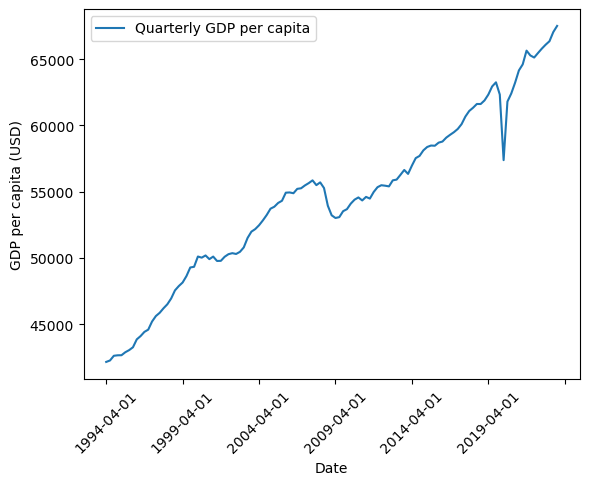

In [33]:
#Plotting a scatter plot to understand the trend in GDP per capita over time 
gdp_copy = gdp.copy()
gdp_copy.sort_values(by='Date', ascending=True, inplace=True)
gdp_copy.plot(x='Date', y='Quarterly GDP per capita')
plt.ylabel('GDP per capita (USD)')
plt.xticks(rotation=45)
plt.show()

It can be observed that GDP per capita, except for economic shocks such as the onset of Covid-19, follows a steady upward linear trend. Based on this, we may opt for linear interpolation of daily values for this parameter, which will be performed after the data-join. 

Consumer Price Index (CPI)

In [34]:
cpi.head()

,DATE,USACPIALLMINMEI
0,1994-04-01,62.189632
1,1994-05-01,62.231823
2,1994-06-01,62.442778
3,1994-07-01,62.611543
4,1994-08-01,62.864689


In [35]:
cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DATE             357 non-null    object 
 1   USACPIALLMINMEI  357 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.7+ KB


In [36]:
#Renaming column 
cpi.rename(columns={'USACPIALLMINMEI':'Monthly CPI', 'DATE': 'Date'}, inplace=True)

In [37]:
#Converting date column to datetime object 
cpi['Date'] = pd.to_datetime(cpi['Date'])
#Sorting both datasets by date  
cpi.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
cpi['Date'] = cpi['Date'].dt.strftime('%Y-%m-%d')

In [38]:
cpi.head() # code to check

,Date,Monthly CPI
356,2023-12-01,129.419409
355,2023-11-01,129.548091
354,2023-10-01,129.809676
353,2023-09-01,129.859462
352,2023-08-01,129.537544


As with GDP per capita, we will investigate the relationship between quarterly CPI values to understand how we might impute daily values. 

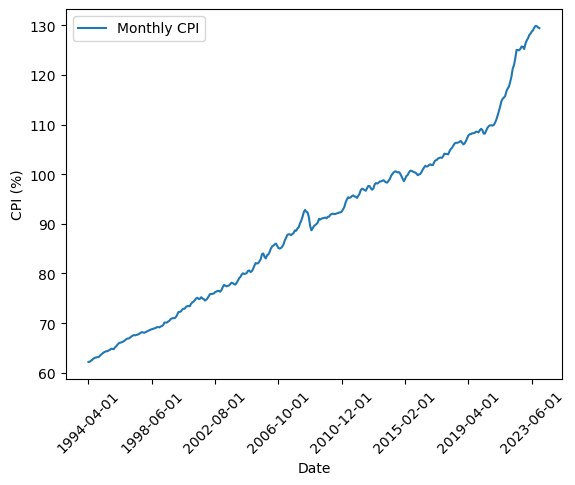

In [39]:
#Plotting a scatter plot to understand the trend in CPI over time 
cpi_copy = cpi.copy()
cpi_copy.sort_values(by='Date', ascending=True, inplace=True)
cpi_copy.plot(x='Date', y='Monthly CPI')
plt.ylabel('CPI (%)')
plt.xticks(rotation=45)
plt.show()

In the case of CPI as well there seems to be an upward linear trend over the measurement period.

Unemployment Rate

In [40]:
unemployment.head()

,DATE,UNRATE
0,1994-04-01,6.4
1,1994-05-01,6.1
2,1994-06-01,6.1
3,1994-07-01,6.1
4,1994-08-01,6.0


In [41]:
#Renaming column 
unemployment.rename(columns={'UNRATE':'Monthly Unemployment Rate (%)', 'DATE': 'Date'}, inplace=True)

In [42]:
#Converting date column to datetime object 
unemployment['Date'] = pd.to_datetime(unemployment['Date'])
#Sorting both datasets by date  
unemployment.sort_values(by='Date', ascending=False, inplace=True)
#Changing formatting of Date column to day-month-year
unemployment['Date'] = unemployment['Date'].dt.strftime('%Y-%m-%d')

In [43]:
unemployment.head() #code to check

,Date,Monthly Unemployment Rate (%)
359,2024-03-01,3.8
358,2024-02-01,3.9
357,2024-01-01,3.7
356,2023-12-01,3.7
355,2023-11-01,3.7


In [44]:
unemployment.loc[unemployment['Date'] == '2018-03-01']

,Date,Monthly Unemployment Rate (%)
287,2018-03-01,4.0


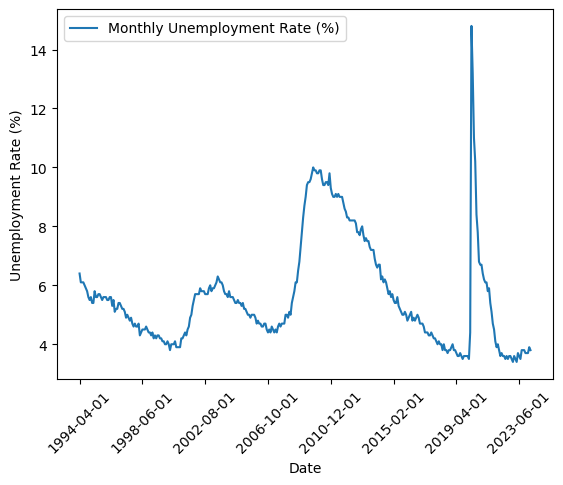

In [45]:
#Plotting a scatter plot to understand the trend in unemployment over time 
unemployment_copy = unemployment.copy()
unemployment_copy.sort_values(by='Date', ascending=True, inplace=True)
unemployment_copy.plot(x='Date', y='Monthly Unemployment Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

In the case of unemployment as well, the trend seems to be non-linear. This will affect our chosen method of imputation later.

### Data Merge  <a class="anchor" id="data-merge"></a>

In [46]:
#Merging all other datasets with the index dataset using reduce 

merge_1 = pd.merge(left=index, right=rf_rate, how='left', on='Date') #merging index with T-bills dataset
merge_1.head()

,Date,Open_x,High_x,Low_x,Close*,Adj Close**,Volume_x,Open_y,High_y,Low_y,Close,Adj Close,Volume_y
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0


In [47]:
merge_2 = pd.merge(left=merge_1, right=gdp, how='left', on='Date')
merge_2.tail()

,Date,Open_x,High_x,Low_x,Close*,Adj Close**,Volume_x,Open_y,High_y,Low_y,Close,Adj Close,Volume_y,Quarterly GDP per capita
7546,1994-04-14,446.26,447.55,443.57,446.38,446.38,275130000,3.54,3.58,3.54,3.58,3.58,0.0,NaN
7547,1994-04-13,447.63,448.57,442.62,446.26,446.26,278030000,3.58,3.59,3.54,3.56,3.56,0.0,NaN
7548,1994-04-12,449.83,450.80,447.33,447.57,447.57,257990000,3.60,3.60,3.55,3.56,3.56,0.0,NaN
7549,1994-04-11,447.12,450.34,447.10,449.87,449.87,243180000,3.57,3.59,3.54,3.54,3.54,0.0,NaN
7550,1994-04-08,450.89,450.89,445.51,447.10,447.10,264090000,3.54,3.55,3.54,3.55,3.55,0.0,NaN


In [48]:
merge_3 = pd.merge(left=merge_2, right=fed_rate, how='left', on='Date')
merge_3.tail()

,Date,Open_x,High_x,Low_x,Close*,Adj Close**,Volume_x,Open_y,High_y,Low_y,Close,Adj Close,Volume_y,Quarterly GDP per capita,Daily Federal Funds Rate (%)
7546,1994-04-14,446.26,447.55,443.57,446.38,446.38,275130000,3.54,3.58,3.54,3.58,3.58,0.0,NaN,3.49
7547,1994-04-13,447.63,448.57,442.62,446.26,446.26,278030000,3.58,3.59,3.54,3.56,3.56,0.0,NaN,3.43
7548,1994-04-12,449.83,450.80,447.33,447.57,447.57,257990000,3.60,3.60,3.55,3.56,3.56,0.0,NaN,3.24
7549,1994-04-11,447.12,450.34,447.10,449.87,449.87,243180000,3.57,3.59,3.54,3.54,3.54,0.0,NaN,3.41
7550,1994-04-08,450.89,450.89,445.51,447.10,447.10,264090000,3.54,3.55,3.54,3.55,3.55,0.0,NaN,3.36


In [49]:
merge_4 = pd.merge(left=merge_3, right=cpi, how='left', on='Date')
merge_4.head()

,Date,Open_x,High_x,Low_x,Close*,Adj Close**,Volume_x,Open_y,High_y,Low_y,Close,Adj Close,Volume_y,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0,NaN,5.33,NaN
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0,NaN,5.33,NaN
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0,NaN,5.33,NaN
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0,NaN,5.33,NaN
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0,NaN,5.33,NaN


In [50]:
merge_5 = pd.merge(left=merge_4, right=unemployment, how='left', on='Date')
merge_5.head()

,Date,Open_x,High_x,Low_x,Close*,Adj Close**,Volume_x,Open_y,High_y,Low_y,Close,Adj Close,Volume_y,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0,NaN,5.33,NaN,NaN
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0,NaN,5.33,NaN,NaN
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0,NaN,5.33,NaN,NaN
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0,NaN,5.33,NaN,NaN
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0,NaN,5.33,NaN,NaN


In [51]:
merge_6 = pd.merge(left=merge_5, right=gold_prices, how='left', on='Date')
merge_6.head()

,Date,Open_x,High_x,Low_x,Close*,Adj Close**,Volume_x,Open_y,High_y,Low_y,Close,Adj Close,Volume_y,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%),Price
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0,NaN,5.33,NaN,NaN,2298.55
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0,NaN,5.33,NaN,NaN,2293.50
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0,NaN,5.33,NaN,NaN,2280.15
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0,NaN,5.33,NaN,NaN,2264.50
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0,NaN,5.33,NaN,NaN,2214.35


In [52]:
merge_6.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           7551 non-null   object 
 1   Open_x                         7551 non-null   float64
 2   High_x                         7551 non-null   float64
 3   Low_x                          7551 non-null   float64
 4   Close*                         7551 non-null   float64
 5   Adj Close**                    7551 non-null   float64
 6   Volume_x                       7551 non-null   int64  
 7   Open_y                         7532 non-null   float64
 8   High_y                         7532 non-null   float64
 9   Low_y                          7532 non-null   float64
 10  Close                          7532 non-null   float64
 11  Adj Close                      7532 non-null   float64
 12  Volume_y                       7532 non-null   f

In [53]:
#Renaming columns to make them more descriptive  
merge_6.rename(columns={'Open_x':'Open_index', 'High_x':'High_index', 'Low_x':'Low_index', 'Close*':'Close_index',
              'Adj Close**': 'Adj_Close_index', 'Volume_x':'Volume_index', 'Open_y':'Open_tbills', 'High_y':'High_tbills',
                       'Low_y':'Low_tbills', 'Close':'Close_tbills', 'Adj Close':'Adj_Close_tbills', 'Volume_y':'Volume_tbills',
                         'Quarterly Growth Rate (%)': 'Quarterly Inflation Rate (%)','Price ':'Daily Gold Prices'}, inplace=True)

In [54]:
merge_6.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           7551 non-null   object 
 1   Open_index                     7551 non-null   float64
 2   High_index                     7551 non-null   float64
 3   Low_index                      7551 non-null   float64
 4   Close_index                    7551 non-null   float64
 5   Adj_Close_index                7551 non-null   float64
 6   Volume_index                   7551 non-null   int64  
 7   Open_tbills                    7532 non-null   float64
 8   High_tbills                    7532 non-null   float64
 9   Low_tbills                     7532 non-null   float64
 10  Close_tbills                   7532 non-null   float64
 11  Adj_Close_tbills               7532 non-null   float64
 12  Volume_tbills                  7532 non-null   f

In [55]:
#Reordering the columns 
column_list = list(merge_6.columns) #creating a list of columns 
new_position = 13 #assigning the desired position within the dataframe
column_list.insert(new_position, column_list.pop(17)) #inserting the selected column in the new position
column_list

#Assigning reordered columns to new variable
merged_data = merge_6[column_list]
merged_data

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0,2298.55,NaN,5.33,NaN,NaN
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0,2293.50,NaN,5.33,NaN,NaN
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0,2280.15,NaN,5.33,NaN,NaN
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0,2264.50,NaN,5.33,NaN,NaN
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0,2214.35,NaN,5.33,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7546,1994-04-14,446.26,447.55,443.57,446.38,446.38,275130000,3.540,3.580,3.540,3.580,3.580,0.0,377.65,NaN,3.49,NaN,NaN
7547,1994-04-13,447.63,448.57,442.62,446.26,446.26,278030000,3.580,3.590,3.540,3.560,3.560,0.0,378.50,NaN,3.43,NaN,NaN
7548,1994-04-12,449.83,450.80,447.33,447.57,447.57,257990000,3.600,3.600,3.550,3.560,3.560,0.0,378.00,NaN,3.24,NaN,NaN
7549,1994-04-11,447.12,450.34,447.10,449.87,449.87,243180000,3.570,3.590,3.540,3.540,3.540,0.0,381.75,NaN,3.41,NaN,NaN


## Exploratory Data Analysis <a class="anchor" id="EDA"></a>

In [60]:
master = merged_data.copy()

In [61]:
master.describe() #summary table 

,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
count,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7.551000e+03,7532.000000,7532.000000,7532.000000,7532.000000,7532.000000,7532.000000,7551.000000,61.000000,7551.000000,230.000000,232.000000
mean,1782.891747,1793.442400,1771.678339,1783.288041,1783.288041,2.795093e+09,2.313298,2.327224,2.295921,2.311398,2.311398,932.103027,950.091955,54409.065574,2.490058,90.469071,5.655603
std,1099.001231,1104.502857,1093.258011,1099.246680,1099.246680,1.751353e+09,2.117538,2.123007,2.110908,2.117197,2.117197,12047.324123,575.187838,6007.000352,2.253963,17.698778,1.928610
min,441.500000,444.720000,438.830000,441.490000,441.490000,1.499000e+07,-0.108000,-0.100000,-0.235000,-0.105000,-0.105000,0.000000,252.800000,42264.000000,0.040000,62.442778,3.500000
25%,1094.450000,1100.155000,1085.645000,1094.100000,1094.100000,1.192550e+09,0.135000,0.138000,0.125000,0.130000,0.130000,0.000000,381.850000,50302.000000,0.160000,74.984073,4.300000
50%,1342.610000,1351.960000,1332.830000,1342.840000,1342.840000,3.085720e+09,1.687000,1.697000,1.671500,1.681000,1.681000,0.000000,935.500000,54401.000000,1.760000,91.290920,5.100000
75%,2169.025000,2174.770000,2160.390000,2169.620000,2169.620000,3.969490e+09,4.715500,4.735000,4.690000,4.710000,4.710000,0.000000,1354.375000,58376.000000,5.080000,101.853137,6.100000
max,5257.970000,5264.850000,5245.820000,5254.350000,5254.350000,1.145623e+10,6.210000,6.230000,6.210000,6.220000,6.220000,159700.000000,2298.550000,65648.000000,7.800000,129.859462,14.800000


In [62]:
#Summary for select columns for report

select_columns = ['Open_index', 'Open_tbills', 'Daily Gold Prices', 'Quarterly GDP per capita', 'Daily Federal Funds Rate (%)',
                 'Monthly CPI', 'Monthly Unemployment Rate (%)']
summary_df = master[select_columns]

summary_df.describe()

,Open_index,Open_tbills,Daily Gold Prices,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
count,7551.000000,7532.000000,7551.000000,61.000000,7551.000000,230.000000,232.000000
mean,1782.891747,2.313298,950.091955,54409.065574,2.490058,90.469071,5.655603
std,1099.001231,2.117538,575.187838,6007.000352,2.253963,17.698778,1.928610
min,441.500000,-0.108000,252.800000,42264.000000,0.040000,62.442778,3.500000
25%,1094.450000,0.135000,381.850000,50302.000000,0.160000,74.984073,4.300000
50%,1342.610000,1.687000,935.500000,54401.000000,1.760000,91.290920,5.100000
75%,2169.025000,4.715500,1354.375000,58376.000000,5.080000,101.853137,6.100000
max,5257.970000,6.210000,2298.550000,65648.000000,7.800000,129.859462,14.800000


In [164]:
master.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7532 non-null   float64       
 8   High_tbills                    7532 non-null   float64       
 9   Low_tbills                     7532 non-null   float64       
 10  Close_tbills                   7532 non-null   float64       
 11  Adj_Close_tbills 

### Time-Series  <a class="anchor" id="time-series"></a>

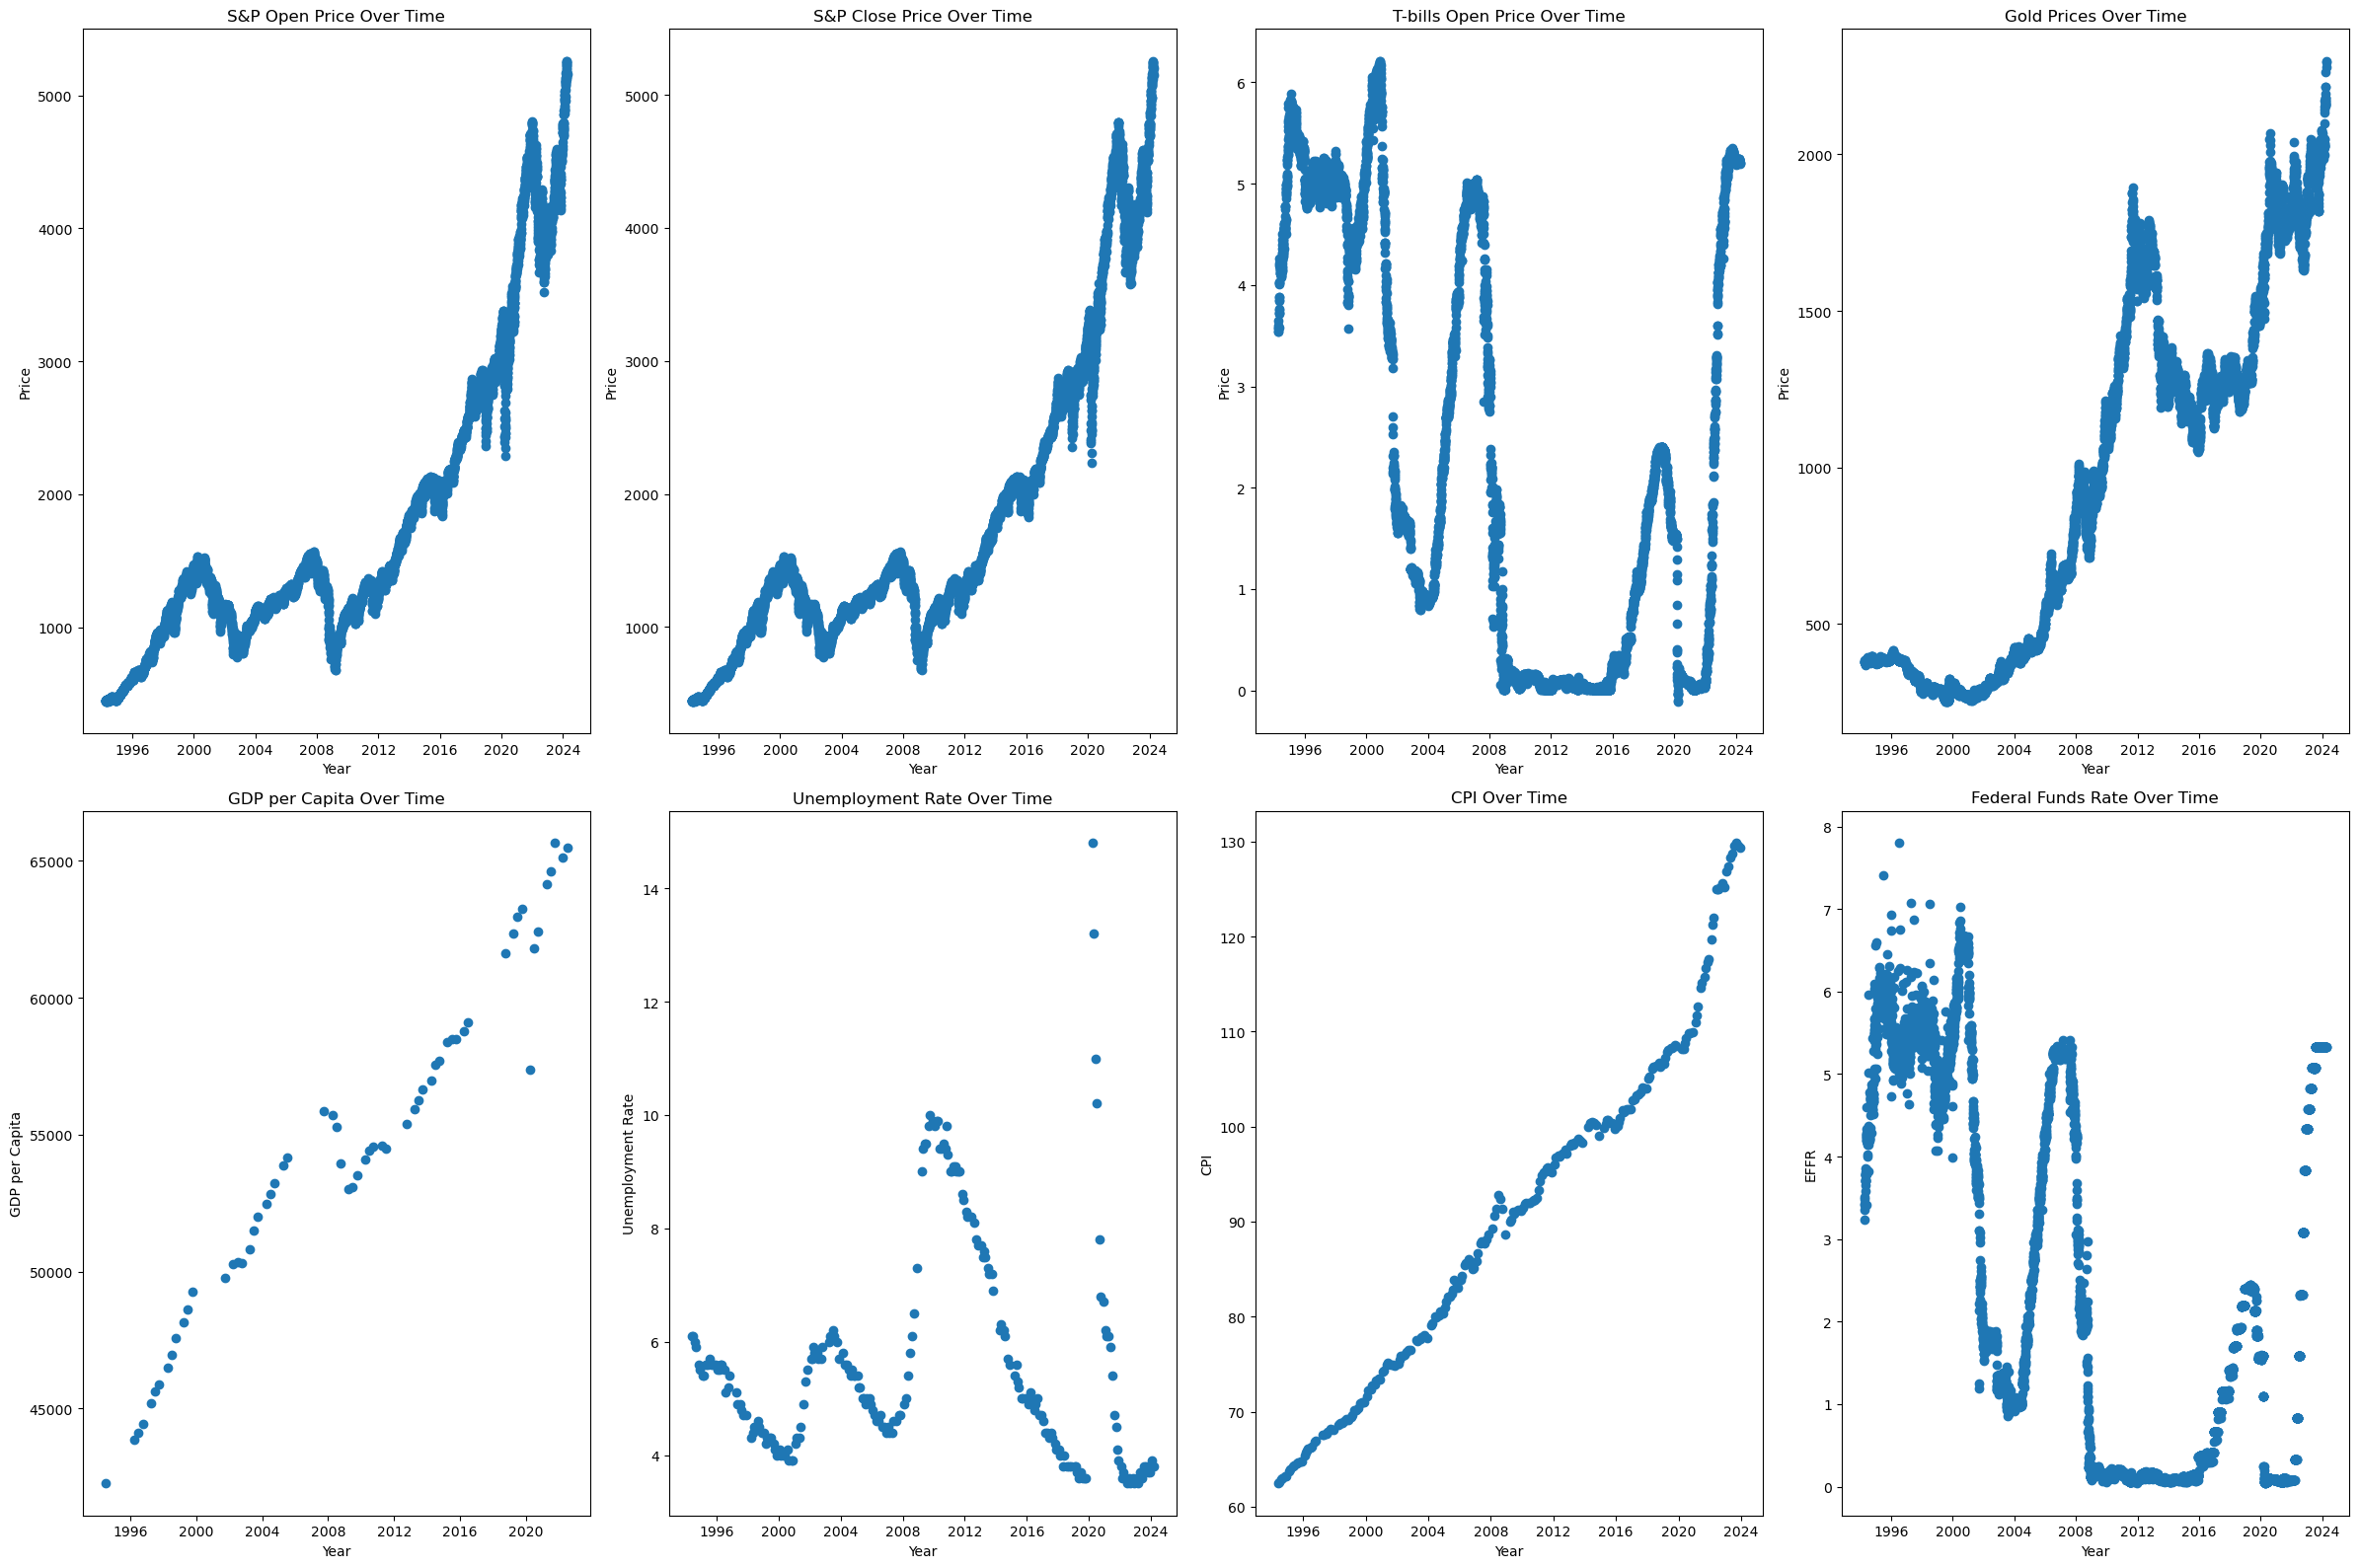

In [63]:
# Converting 'Date' to a datetime object 
master['Date'] = pd.to_datetime(master['Date'])

# Defining the figure and subplots
fig, axs = plt.subplots(2, 4, figsize=(24, 16))  # 3 rows and 4 columns

# Plotting S&P Open price over time
axs[0, 0].scatter(master['Date'], master['Open_index'])
axs[0, 0].set_title('S&P Open Price Over Time')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Price')

# Plotting S&P Close price over time
axs[0, 1].scatter(master['Date'], master['Close_index'])
axs[0, 1].set_title('S&P Close Price Over Time')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Price')

# Plotting T-bill Open price over time
axs[0, 2].scatter(master['Date'], master['Open_tbills'])
axs[0, 2].set_title('T-bills Open Price Over Time')
axs[0, 2].set_xlabel('Year')
axs[0, 2].set_ylabel('Price')

# Plotting Gold price over time
axs[0, 3].scatter(master['Date'], master['Daily Gold Prices'])
axs[0, 3].set_title('Gold Prices Over Time')
axs[0, 3].set_xlabel('Year')
axs[0, 3].set_ylabel('Price')

# Plotting GDP per capita over time
axs[1, 0].scatter(master['Date'], master['Quarterly GDP per capita'])
axs[1, 0].set_title('GDP per Capita Over Time')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('GDP per Capita')

# Plotting Unemployment rate over time
axs[1, 1].scatter(master['Date'], master['Monthly Unemployment Rate (%)'])
axs[1, 1].set_title('Unemployment Rate Over Time')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Unemployment Rate')

# Plotting Inflation rate over time
axs[1, 2].scatter(master['Date'], master['Monthly CPI'])
axs[1, 2].set_title('CPI Over Time')
axs[1, 2].set_xlabel('Year')
axs[1, 2].set_ylabel('CPI')

# Plotting Federal Funds rate over time 
axs[1, 3].scatter(master['Date'], master['Daily Federal Funds Rate (%)'])
axs[1, 3].set_title('Federal Funds Rate Over Time')
axs[1, 3].set_xlabel('Year')
axs[1, 3].set_ylabel('EFFR')

# Adjust the subplots layout
plt.tight_layout()

# Show the plot
plt.show()

We observe that for certain attributes such as GDP per capita, Unemployment Rate and Inflation Rate, there are gaps in the data, as these data are reported quarterly or monthly. We will be using different imputation methods to estimate daily values for these later in the notebook.

### Correlation <a class="anchor" id="correlation"></a>

In [64]:
#Calculating correlation coefficient between different numerical attributes 
master_numeric = master.select_dtypes(include=[np.number]) #assigning all numeric variables in df to new variable 
corr_matrix = master_numeric.corr()
corr_matrix['Open_index']

Open_index                       1.000000
High_index                       0.999939
Low_index                        0.999911
Close_index                      0.999842
Adj_Close_index                  0.999842
Volume_index                     0.508409
Open_tbills                     -0.191033
High_tbills                     -0.191856
Low_tbills                      -0.190776
Close_tbills                    -0.190873
Adj_Close_tbills                -0.190873
Volume_tbills                   -0.041434
Daily Gold Prices                0.783336
Quarterly GDP per capita         0.879773
Daily Federal Funds Rate (%)    -0.227446
Monthly CPI                      0.888543
Monthly Unemployment Rate (%)   -0.298865
Name: Open_index, dtype: float64

/var/folders/w2/rv9s6p814n548_nhp6nhhyvw0000gn/T/ipykernel_9668/486991130.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = master.corr()


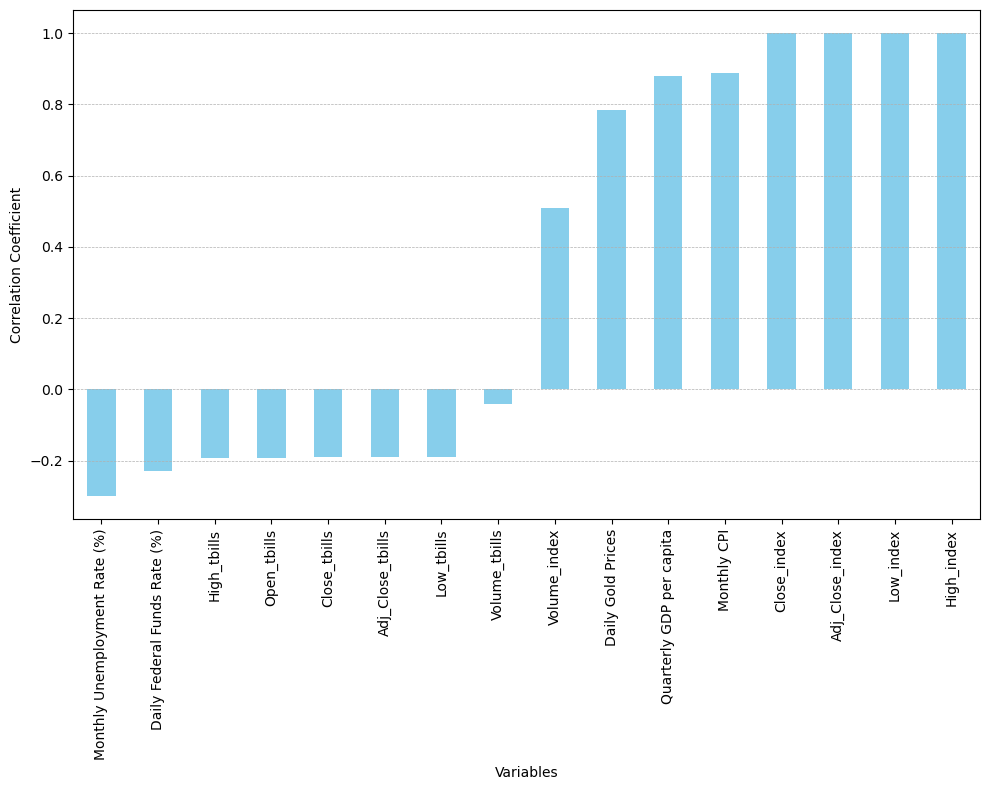

In [65]:
#Plotting the correlation coefficient with Open_index

corr_matrix = master.corr()

correlation_with_open = corr_matrix['Open_index'].drop('Open_index', errors='ignore').sort_values()

plt.figure(figsize=(10, 8))
correlation_with_open.plot(kind='bar', color='skyblue')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()


In [66]:
corr_matrix['Daily Federal Funds Rate (%)']

Open_index                      -0.227446
High_index                      -0.227504
Low_index                       -0.227119
Close_index                     -0.227323
Adj_Close_index                 -0.227323
Volume_index                    -0.626834
Open_tbills                      0.992101
High_tbills                      0.992335
Low_tbills                       0.991434
Close_tbills                     0.992032
Adj_Close_tbills                 0.992032
Volume_tbills                    0.004915
Daily Gold Prices               -0.567560
Quarterly GDP per capita        -0.700361
Daily Federal Funds Rate (%)     1.000000
Monthly CPI                     -0.561082
Monthly Unemployment Rate (%)   -0.530067
Name: Daily Federal Funds Rate (%), dtype: float64

/var/folders/w2/rv9s6p814n548_nhp6nhhyvw0000gn/T/ipykernel_9668/298271863.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = master.corr()


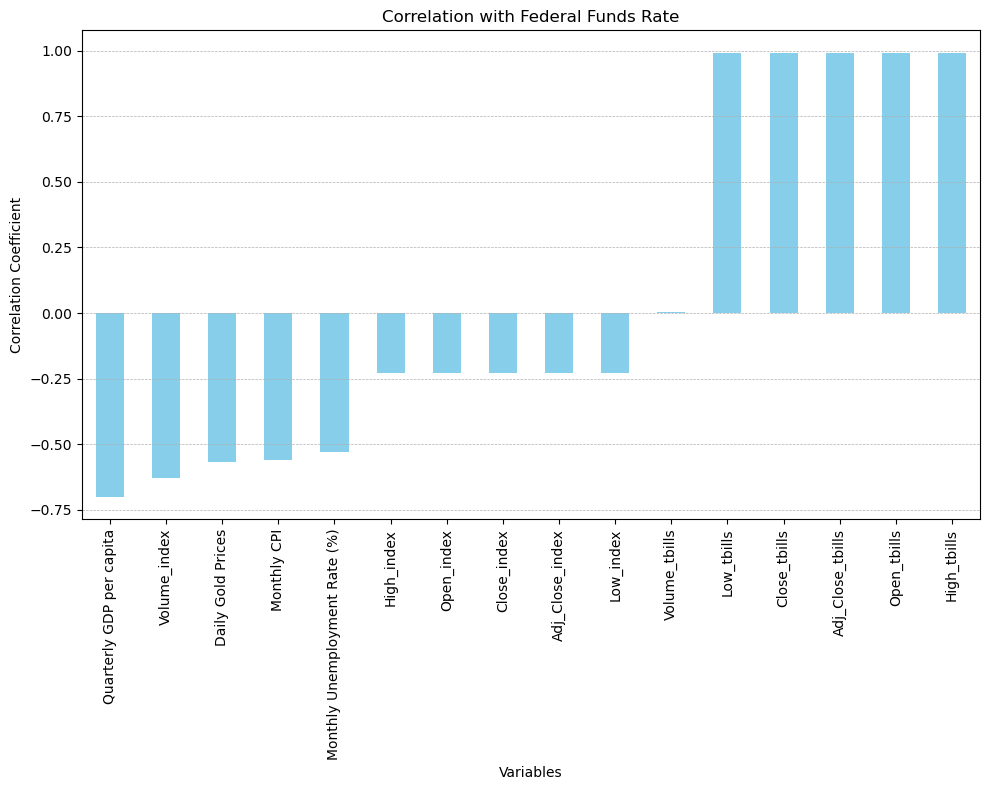

In [67]:
#Plotting the correlation coefficients with Federal Funds Rate 

corr_matrix = master.corr()

correlation_with_open = corr_matrix['Daily Federal Funds Rate (%)'].drop('Daily Federal Funds Rate (%)', errors='ignore').sort_values()

plt.figure(figsize=(10, 8))
correlation_with_open.plot(kind='bar', color='skyblue')
plt.title('Correlation with Federal Funds Rate')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()


In [68]:
corr_matrix['Monthly CPI']

Open_index                       0.888543
High_index                       0.888495
Low_index                        0.888066
Close_index                      0.887839
Adj_Close_index                  0.887839
Volume_index                     0.799289
Open_tbills                     -0.516196
High_tbills                     -0.517070
Low_tbills                      -0.517027
Close_tbills                    -0.516987
Adj_Close_tbills                -0.516987
Volume_tbills                   -0.048950
Daily Gold Prices                0.923473
Quarterly GDP per capita         0.971409
Daily Federal Funds Rate (%)    -0.561082
Monthly CPI                      1.000000
Monthly Unemployment Rate (%)   -0.006624
Name: Monthly CPI, dtype: float64

/var/folders/w2/rv9s6p814n548_nhp6nhhyvw0000gn/T/ipykernel_9668/1859162166.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = master.corr()


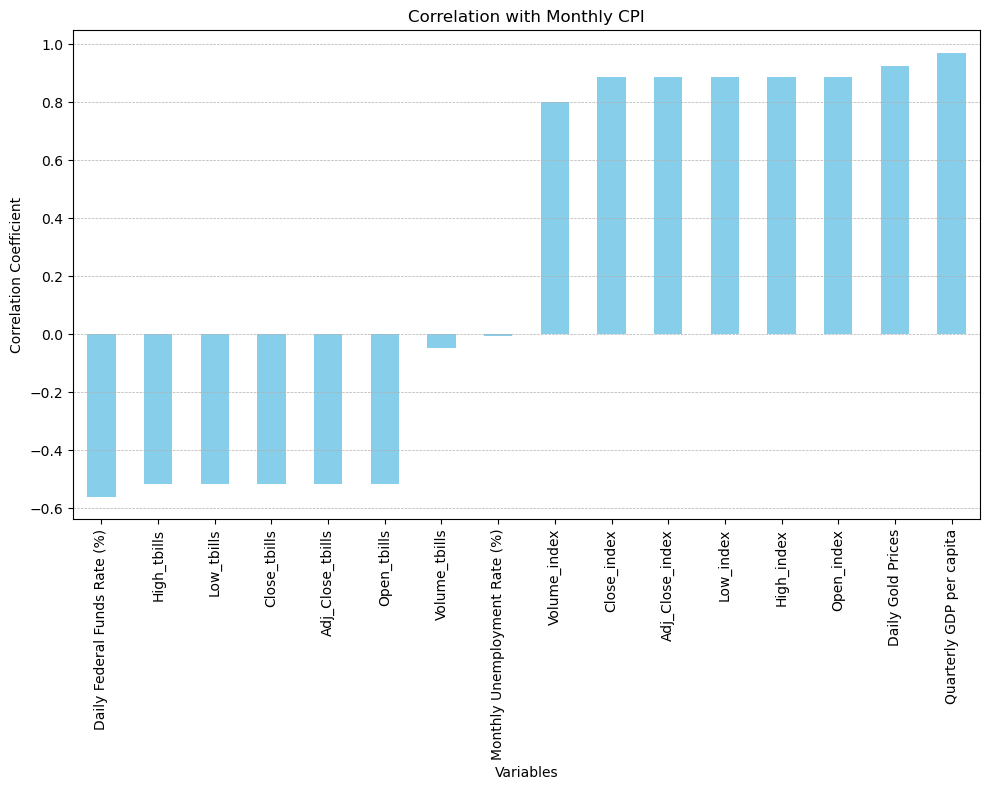

In [69]:
#Plotting the correlation coefficients with CPI 

corr_matrix = master.corr()

correlation_with_open = corr_matrix['Monthly CPI'].drop('Monthly CPI', errors='ignore').sort_values()

plt.figure(figsize=(10, 8))
correlation_with_open.plot(kind='bar', color='skyblue')
plt.title('Correlation with Monthly CPI')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()


In [70]:
corr_matrix['Quarterly GDP per capita']

Open_index                       0.879773
High_index                       0.880228
Low_index                        0.879645
Close_index                      0.879466
Adj_Close_index                  0.879466
Volume_index                     0.701285
Open_tbills                     -0.696972
High_tbills                     -0.698256
Low_tbills                      -0.697310
Close_tbills                    -0.698365
Adj_Close_tbills                -0.698365
Volume_tbills                         NaN
Daily Gold Prices                0.858815
Quarterly GDP per capita         1.000000
Daily Federal Funds Rate (%)    -0.700361
Monthly CPI                      0.971409
Monthly Unemployment Rate (%)    0.009348
Name: Quarterly GDP per capita, dtype: float64

/var/folders/w2/rv9s6p814n548_nhp6nhhyvw0000gn/T/ipykernel_9668/1452551611.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = master.corr()


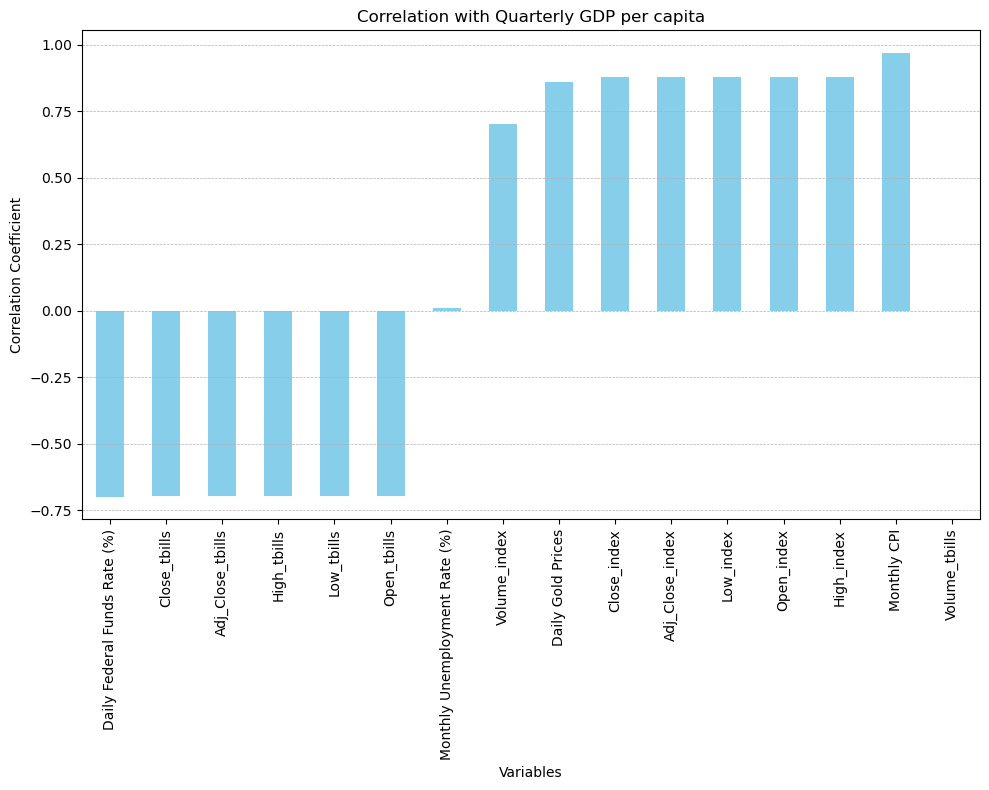

In [71]:
#Plotting the correlation coefficients with Quarterly GDP per capita 

corr_matrix = master.corr()

correlation_with_open = corr_matrix['Quarterly GDP per capita'].drop('Quarterly GDP per capita', errors='ignore').sort_values()

plt.figure(figsize=(10, 8))
correlation_with_open.plot(kind='bar', color='skyblue')
plt.title('Correlation with Quarterly GDP per capita')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

### Scatterplots <a class="anchor" id="scatterplots"></a>

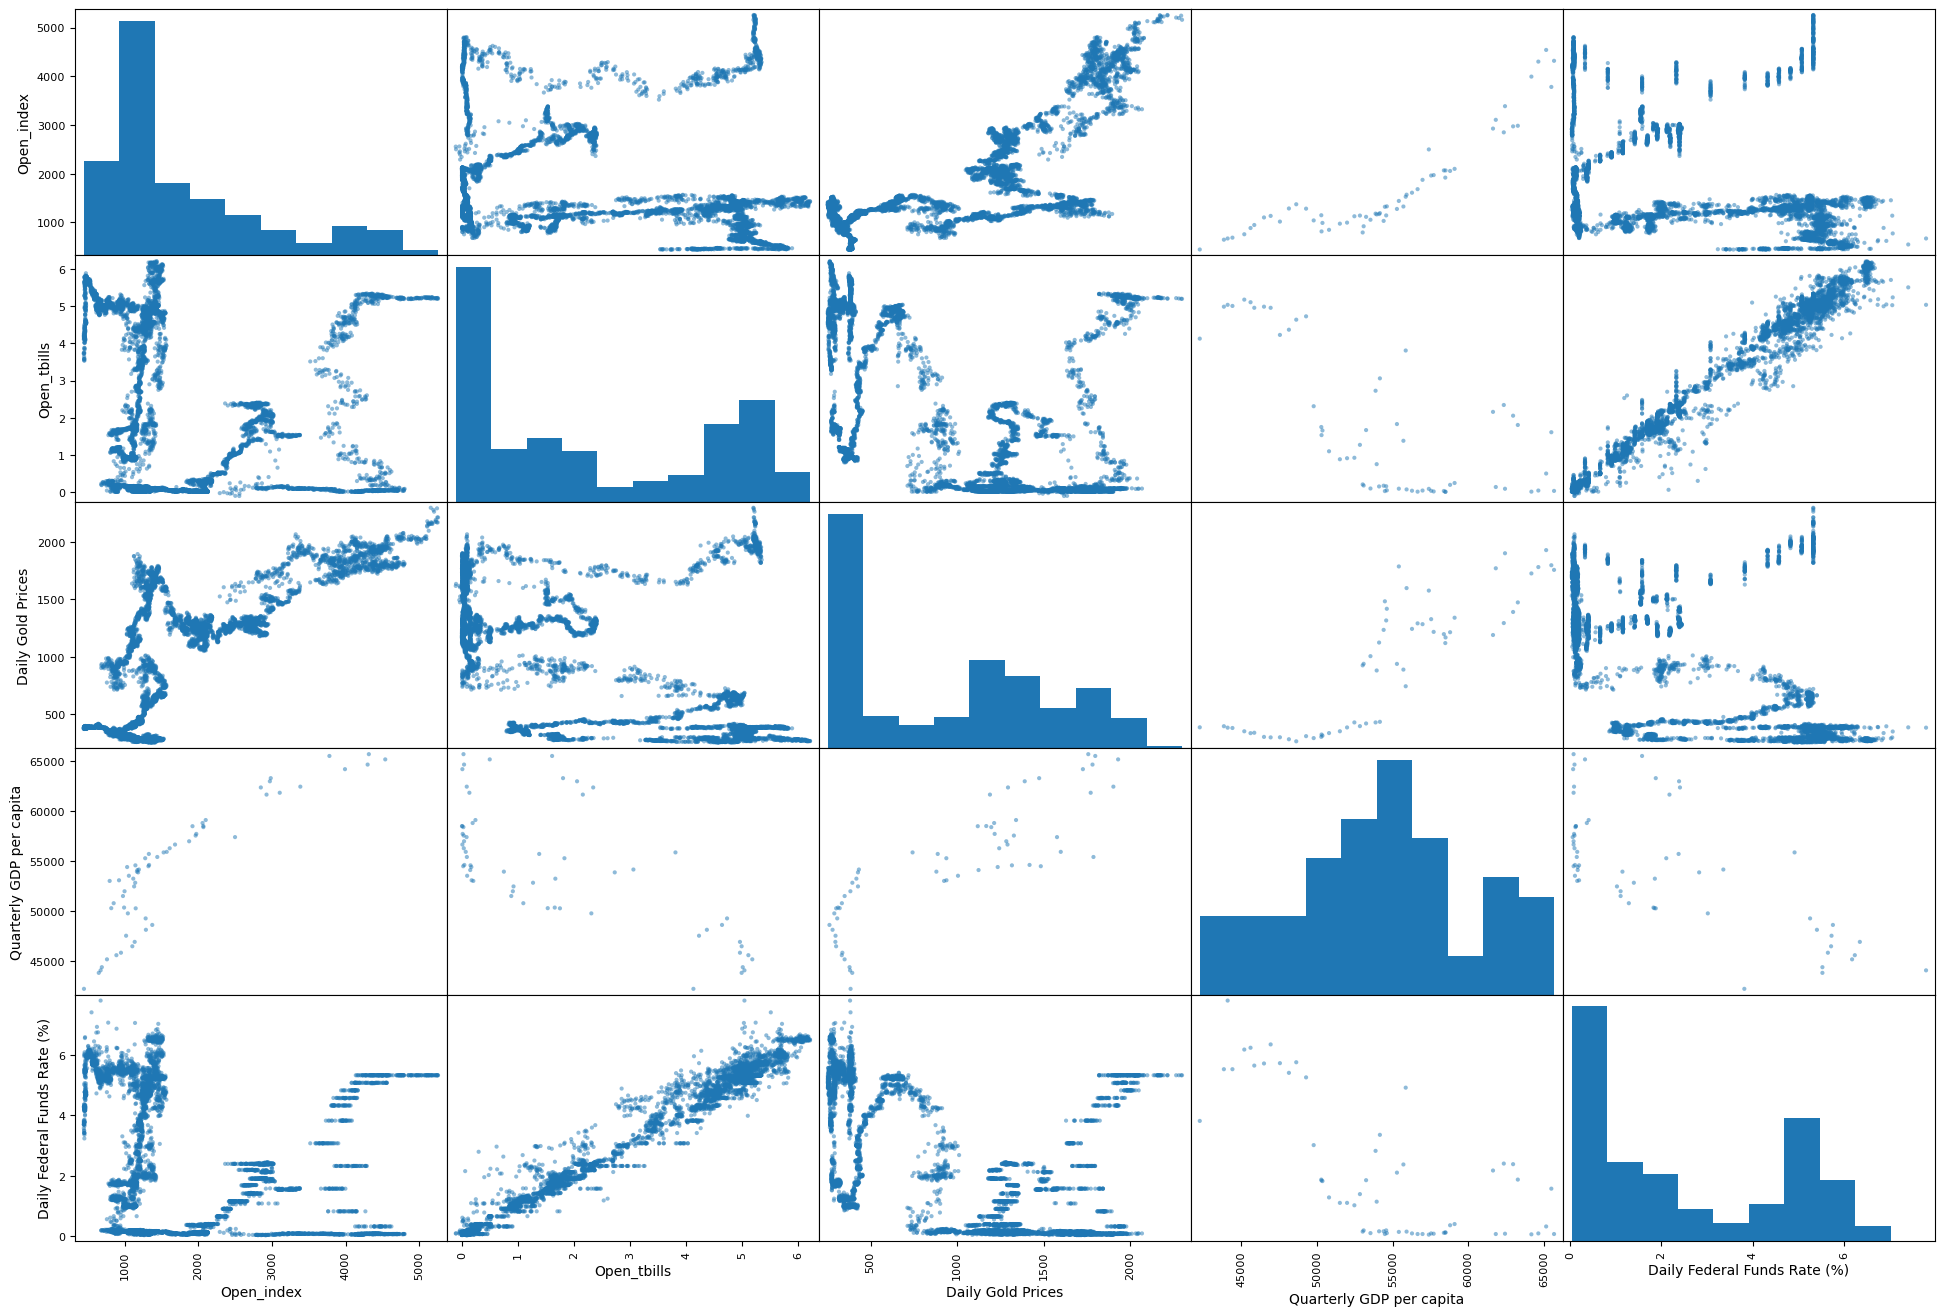

In [72]:
#Plotting a scatter matrix by handpicking select attributes that seem correlated with index opening prices 
attributes = ['Open_index','Open_tbills', 'Daily Gold Prices', 'Quarterly GDP per capita', 'Daily Federal Funds Rate (%)']
scatter_matrix(master_numeric[attributes], figsize=(24,16))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

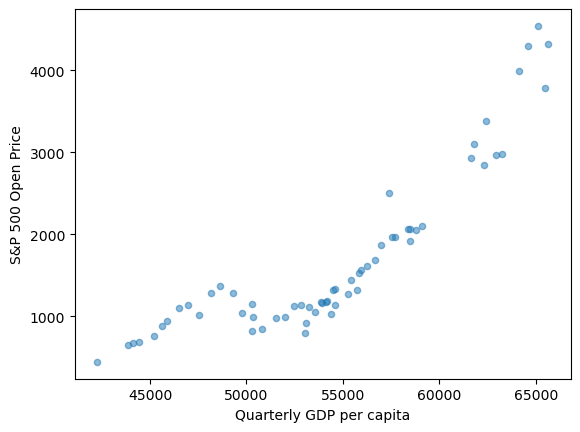

In [73]:
#Looking at the relationship between index opening price and the GDP per capita more closely
master.plot(kind='scatter', x='Quarterly GDP per capita', y = 'Open_index', alpha = 0.5)
plt.xlabel('Quarterly GDP per capita')
plt.ylabel ('S&P 500 Open Price')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

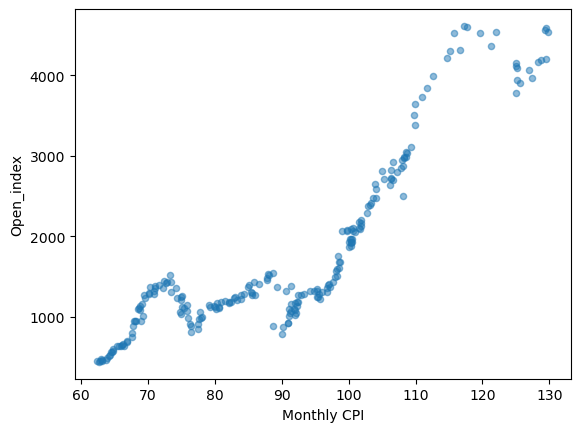

In [74]:
#Looking at the relationship between index opening price and CPI more closely
master.plot(kind='scatter', x='Monthly CPI', y = 'Open_index', alpha = 0.5)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

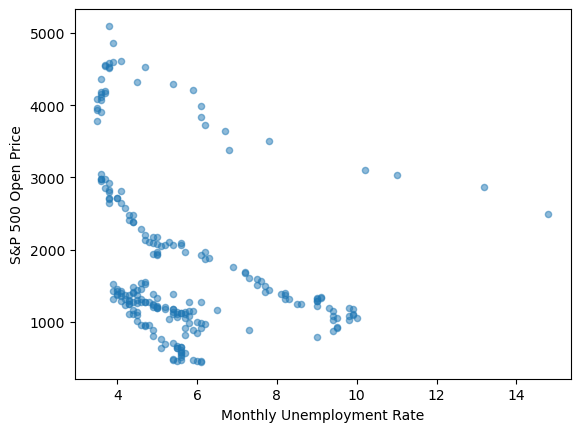

In [75]:
#Looking at the relationship between index opening price and unemployment rate more closely
master.plot(kind='scatter', x='Monthly Unemployment Rate (%)', y = 'Open_index', alpha = 0.5)
plt.xlabel('Monthly Unemployment Rate')
plt.ylabel ('S&P 500 Open Price')
plt.show

# Data Cleaning <a class="anchor" id="data-cleaning"></a>

## Handling Missing Values <a class="anchor" id="handling-missing-values"></a>

While we handled these missing values in the source datasets earlier on, the NaN values post the data merge we can assume are due to lack of corresponding key values in the right datasets. It should be noted that certain datasets did not date back to the start date of the S&P data while some have a different reporting frequency. We will address these NaN values using different methods of imputation. 

In [76]:
master.info() #checking count of missing values

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7532 non-null   float64       
 8   High_tbills                    7532 non-null   float64       
 9   Low_tbills                     7532 non-null   float64       
 10  Close_tbills                   7532 non-null   float64       
 11  Adj_Close_tbills 

In [77]:
master.loc[master['Open_tbills'].isnull()]

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
1859,2016-11-11,2162.71,2165.92,2152.49,2164.45,2164.45,4993990000,NaN,NaN,NaN,NaN,NaN,NaN,1236.45,NaN,0.41,NaN,NaN
1883,2016-10-10,2160.39,2169.60,2160.39,2163.66,2163.66,2881970000,NaN,NaN,NaN,NaN,NaN,NaN,1259.50,NaN,0.40,NaN,NaN
3393,2010-10-11,1165.32,1168.68,1162.02,1165.32,1165.32,2505900000,NaN,NaN,NaN,NaN,NaN,NaN,1351.50,NaN,0.18,NaN,NaN
4401,2006-10-09,1349.58,1352.69,1346.55,1350.66,1350.66,1935170000,NaN,NaN,NaN,NaN,NaN,NaN,575.25,NaN,5.22,NaN,NaN
4628,2005-11-11,1230.96,1235.70,1230.72,1234.72,1234.72,1773140000,NaN,NaN,NaN,NaN,NaN,NaN,466.75,NaN,3.98,NaN,NaN
4652,2005-10-10,1195.90,1196.52,1186.12,1187.33,1187.33,2195990000,NaN,NaN,NaN,NaN,NaN,NaN,473.20,NaN,3.73,NaN,NaN
5133,2003-11-11,1047.11,1048.23,1043.46,1046.57,1046.57,1162500000,NaN,NaN,NaN,NaN,NaN,NaN,387.80,NaN,0.99,NaN,NaN
6137,1999-11-11,1373.46,1382.12,1372.19,1381.46,1381.46,891300000,NaN,NaN,NaN,NaN,NaN,NaN,296.00,NaN,5.27,NaN,NaN
6160,1999-10-11,1336.02,1339.23,1332.96,1335.21,1335.21,655900000,NaN,NaN,NaN,NaN,NaN,NaN,317.75,NaN,5.10,NaN,NaN
6389,1998-11-11,1128.26,1136.25,1117.40,1120.97,1120.97,715700000,NaN,NaN,NaN,NaN,NaN,NaN,293.50,NaN,4.84,NaN,NaN


In [78]:
#Creating copy of master 
master_copy = master.copy()

In [79]:
#Using linear interpolation for T-bill columns 
master_copy['Open_tbills'] = master_copy['Open_tbills'].interpolate(method='linear')
master_copy['High_tbills'] = master_copy['High_tbills'].interpolate(method='linear')
master_copy['Low_tbills'] = master_copy['Low_tbills'].interpolate(method='linear')
master_copy['Close_tbills'] = master_copy['Close_tbills'].interpolate(method='linear')
master_copy['Adj_Close_tbills'] = master_copy['Adj_Close_tbills'].interpolate(method='linear')
master_copy['Volume_tbills'] = master_copy['Volume_tbills'].interpolate(method='linear')

In [80]:
master_copy.info() #code to check

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7551 non-null   float64       
 8   High_tbills                    7551 non-null   float64       
 9   Low_tbills                     7551 non-null   float64       
 10  Close_tbills                   7551 non-null   float64       
 11  Adj_Close_tbills 

We have observed earlier that GDP per capita follows an upward linear trend from quarter to quarter. We therefore assume that it would follow a similar linear trend and may therefore use linear interpolation here as well. 

In [81]:
#Using linear interpolation for GDP column 
master_copy['Quarterly GDP per capita'] = master_copy['Quarterly GDP per capita'].interpolate(method='linear')

In [82]:
master_copy['Quarterly GDP per capita'].isnull().sum() 

442

We notice there are still missing values under the column.

In [83]:
master_copy.loc[master_copy['Date'] == '1994-04-01']

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)


In [84]:
gdp['Date'].min()

'1994-04-01'

In [85]:
index['Date'].min()

'1994-04-08'

An investigation of the source datasets indicates that the left join performed on the datasets dropped some of the values, which is responsible for the missing values here. 

We will address this by assigning an initial value for the GDP column from the source dataset. The assigned value is the reported GDP per capita for the quarter ending April 1, 1994. 

In [86]:
master_copy.iloc[0, master_copy.columns.get_loc('Quarterly GDP per capita')] = gdp.iloc[-1, gdp.columns.get_loc('Quarterly GDP per capita')]

In [87]:
master_copy.head()

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,Quarterly GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0,2298.55,42154.0,5.33,NaN,NaN
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0,2293.50,NaN,5.33,NaN,NaN
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0,2280.15,NaN,5.33,NaN,NaN
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0,2264.50,NaN,5.33,NaN,NaN
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0,2214.35,NaN,5.33,NaN,NaN


In [88]:
#Applying linear interpolation to the GDP data again
master_copy['Quarterly GDP per capita'] = master_copy['Quarterly GDP per capita'].interpolate(method='linear')

In [89]:
#Renaming column 
master_copy = master_copy.rename(columns={'Quarterly GDP per capita': 'GDP per capita'})

In [90]:
master_copy.info() # code to check

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7551 non-null   float64       
 8   High_tbills                    7551 non-null   float64       
 9   Low_tbills                     7551 non-null   float64       
 10  Close_tbills                   7551 non-null   float64       
 11  Adj_Close_tbills 

In [91]:
#Applying Linear Interpolation to CPI
master_copy['Monthly CPI'] = master_copy['Monthly CPI'].interpolate(method='linear')

In [92]:
master_copy['Monthly CPI'].isnull().sum()

85

An investigation of the source datasets indicates that the left join performed on the datasets dropped some of the values, which is responsible for the missing values here. 

In [93]:
#Assigning initial value from the source dataset 
master_copy.iloc[0, master_copy.columns.get_loc('Monthly CPI')] = cpi.iloc[-1, cpi.columns.get_loc('Monthly CPI')]

In [94]:
#Reapplying Linear Interpolation 
master_copy['Monthly CPI'] = master_copy['Monthly CPI'].interpolate(method='linear')

In [95]:
master_copy['Monthly CPI'].isnull().sum()  #code to check

0

In [96]:
master_copy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7551 non-null   float64       
 8   High_tbills                    7551 non-null   float64       
 9   Low_tbills                     7551 non-null   float64       
 10  Close_tbills                   7551 non-null   float64       
 11  Adj_Close_tbills 

The unemployment rate for a given month is a stock variable that is not based on an aggregation of daily estimates. It is measured at a specific point in time, i.e., the end of the month. Therefore, we may estimate daily values using backward fill. 

In [97]:
master_copy[master_copy['Monthly Unemployment Rate (%)'].isnull()]

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,5.215,5.215,0.0,2298.55,42154.000000,5.33,62.189632,NaN
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,5.203,5.203,0.0,2293.50,42206.748869,5.33,62.980571,NaN
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,5.210,5.210,0.0,2280.15,42259.497738,5.33,63.771509,NaN
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,5.213,5.213,0.0,2264.50,42312.246606,5.33,64.562448,NaN
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,5.218,5.218,0.0,2214.35,42364.995475,5.33,65.353386,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7546,1994-04-14,446.26,447.55,443.57,446.38,446.38,275130000,3.540,3.580,3.540,3.580,3.580,0.0,377.65,42264.000000,3.49,62.442778,NaN
7547,1994-04-13,447.63,448.57,442.62,446.26,446.26,278030000,3.580,3.590,3.540,3.560,3.560,0.0,378.50,42264.000000,3.43,62.442778,NaN
7548,1994-04-12,449.83,450.80,447.33,447.57,447.57,257990000,3.600,3.600,3.550,3.560,3.560,0.0,378.00,42264.000000,3.24,62.442778,NaN
7549,1994-04-11,447.12,450.34,447.10,449.87,449.87,243180000,3.570,3.590,3.540,3.540,3.540,0.0,381.75,42264.000000,3.41,62.442778,NaN


In [98]:
#Applying backward fill
master_copy['Monthly Unemployment Rate (%)'].fillna(method='bfill', inplace=True)

In [99]:
master_copy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7551 non-null   float64       
 8   High_tbills                    7551 non-null   float64       
 9   Low_tbills                     7551 non-null   float64       
 10  Close_tbills                   7551 non-null   float64       
 11  Adj_Close_tbills 

In [100]:
master_copy[master_copy['Monthly Unemployment Rate (%)'].isnull()]

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)
7515,1994-05-31,457.32,457.61,455.16,456.50,456.50,216700000,4.17,4.19,4.17,4.17,4.17,0.0,387.60,42264.0,4.60,62.442778,NaN
7516,1994-05-27,457.03,457.33,454.67,457.33,457.33,186430000,4.16,4.20,4.16,4.17,4.17,0.0,385.40,42264.0,4.19,62.442778,NaN
7517,1994-05-26,456.33,457.77,455.79,457.06,457.06,255740000,4.15,4.16,4.13,4.15,4.15,0.0,384.90,42264.0,4.23,62.442778,NaN
7518,1994-05-25,454.84,456.34,452.20,456.34,456.34,254420000,4.22,4.23,4.17,4.18,4.18,0.0,387.30,42264.0,4.24,62.442778,NaN
7519,1994-05-24,453.21,456.77,453.21,454.81,454.81,280040000,4.23,4.23,4.20,4.21,4.21,0.0,388.00,42264.0,4.19,62.442778,NaN
7520,1994-05-23,454.92,454.92,451.79,453.20,453.20,249420000,4.14,4.16,4.14,4.16,4.16,0.0,386.45,42264.0,4.28,62.442778,NaN
7521,1994-05-20,456.48,456.48,454.22,454.92,454.92,295180000,4.13,4.15,4.13,4.14,4.14,0.0,383.15,42264.0,4.21,62.442778,NaN
7522,1994-05-19,453.69,456.88,453.00,456.48,456.48,303680000,4.18,4.19,4.13,4.13,4.13,0.0,383.30,42264.0,4.23,62.442778,NaN
7523,1994-05-18,449.39,454.45,448.87,453.69,453.69,337670000,4.20,4.23,4.18,4.19,4.19,0.0,379.60,42264.0,4.26,62.442778,NaN
7524,1994-05-17,444.49,449.37,443.70,449.37,449.37,311280000,4.20,4.25,4.16,4.19,4.19,0.0,382.55,42264.0,4.27,62.442778,NaN


In [101]:
master_copy.loc[master_copy['Date'] == '2018-04-01']

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,Volume_tbills,Daily Gold Prices,GDP per capita,Daily Federal Funds Rate (%),Monthly CPI,Monthly Unemployment Rate (%)


In [102]:
unemployment.loc[unemployment['Date'] == '2018-03-01']

,Date,Monthly Unemployment Rate (%)
287,2018-03-01,4.0


In [103]:
unemployment.loc[unemployment['Date'] == '2018-04-01']

,Date,Monthly Unemployment Rate (%)
288,2018-04-01,4.0


An investigation of the source dataset indicates that the remaining missing values which were not filled during the first bfill were due to a loss of data during the data join.

We observe that the month for which the column value is missing does not change from the previous month. Therefore, here we can use forward-fill. 

In [104]:
#Applying forward fill to unemployment 
master_copy['Monthly Unemployment Rate (%)'].fillna(method='ffill', inplace=True)

In [105]:
master_copy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           7551 non-null   datetime64[ns]
 1   Open_index                     7551 non-null   float64       
 2   High_index                     7551 non-null   float64       
 3   Low_index                      7551 non-null   float64       
 4   Close_index                    7551 non-null   float64       
 5   Adj_Close_index                7551 non-null   float64       
 6   Volume_index                   7551 non-null   int64         
 7   Open_tbills                    7551 non-null   float64       
 8   High_tbills                    7551 non-null   float64       
 9   Low_tbills                     7551 non-null   float64       
 10  Close_tbills                   7551 non-null   float64       
 11  Adj_Close_tbills 

In [106]:
#Renaming columns 
master_copy = master_copy.rename(columns={'Daily Gold Prices': 'Gold_price', 'Monthly Unemployment Rate (%)':'Unemployment Rate (%)', 'Monthly CPI': 'CPI' , 'Daily Federal Funds Rate (%)': 'Federal Funds Rate (%)'})

## Feature Engineering <a class="anchor" id="feature-engineering"></a>

In [107]:
#Creating a copy of the cleaned dataset
master_clean = master_copy.copy()
#Adding new features to the clean dataset
master_clean['Year'] = master_clean['Date'].dt.year
master_clean['Month'] = master_clean['Date'].dt.month
master_clean['Day'] = master_clean['Date'].dt.day
master_clean['Daily Return'] = master_clean['Close_index'].pct_change().fillna(0) * 100
master_clean['7-day SMA'] =  master_clean['Open_index'].rolling(window=7).mean().fillna(0)
master_clean['7-day STD'] =  master_clean['Open_index'].rolling(window=7).std().fillna(0)
master_clean['High-Close'] = master_clean['High_index']-master_clean['Close_index']
master_clean['Low-Open'] = master_clean['Low_index']-master_clean['Open_index']
master_clean['14-day EMA'] = master_clean['Open_index'].ewm(span=14, adjust=False).mean().fillna(0)

In [108]:
#Creating lagged features for open prices up to 7 days prior to the present day t 
for i in range(1, 8):  
    master_clean[f'Open_index_t-{i}'] = master_clean['Open_index'].shift(i)

#Dropping NaN values in lag columns 
master_clean.fillna(0, inplace=True)

In [109]:
master_clean.head()

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,...,High-Close,Low-Open,14-day EMA,Open_index_t-1,Open_index_t-2,Open_index_t-3,Open_index_t-4,Open_index_t-5,Open_index_t-6,Open_index_t-7
0,2024-04-05,5158.95,5222.18,5157.21,5204.34,5204.34,3386780000,5.200,5.218,5.193,...,17.84,-1.74,5158.950000,0.00,0.00,0.00,0.00,0.0,0.0,0.0
1,2024-04-04,5244.05,5256.59,5146.06,5147.21,5147.21,4075680000,5.203,5.205,5.203,...,109.38,-97.99,5170.296667,5158.95,0.00,0.00,0.00,0.0,0.0,0.0
2,2024-04-03,5194.37,5228.75,5194.37,5211.49,5211.49,3703250000,5.210,5.215,5.208,...,17.26,0.00,5173.506444,5244.05,5158.95,0.00,0.00,0.0,0.0,0.0
3,2024-04-02,5204.29,5208.34,5184.05,5205.81,5205.81,3886590000,5.220,5.220,5.208,...,2.53,-20.24,5177.610919,5194.37,5244.05,5158.95,0.00,0.0,0.0,0.0
4,2024-04-01,5257.97,5263.95,5229.20,5243.77,5243.77,3325930000,5.205,5.228,5.205,...,20.18,-28.77,5188.325463,5204.29,5194.37,5244.05,5158.95,0.0,0.0,0.0


We shall also technical indictors of index performance such as the Relative Strength Index (RSI) and Stochastic Oscillator.

In [110]:
## RSI
#Calculating daily changes in close prices
delta = master_clean['Close_index'].diff().fillna(0)

#Separating gains and losses
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

#Calculating the simple moving average of gains and losses
average_gain = gain.rolling(window=14).mean().fillna(0)
average_loss = loss.rolling(window=14).mean().fillna(0)

#Calculating the Relative Strength 
RS = (average_gain / average_loss).fillna(0)

#Calculating the RSI and creating a new column
master_clean['RSI'] = 100 - (100 / (1 + RS))

In [111]:
## Calculating the Stochastic Oscillator
# Defining the trading period
N = 14

# Calculating the lowest low and highest high over the past 'N' days with at least one data point
low_min  = master_clean['Low_index'].rolling(window=N, min_periods=1).min()
high_max = master_clean['High_index'].rolling(window=N, min_periods=1).max()

# Calculating the Stochastic Oscillator and creating a new column 
master_clean['Stochastic Oscillator'] = 100 * np.where((high_max - low_min) == 0, 0, (master_clean['Close_index'] - low_min) / (high_max - low_min)) 

In [112]:
master_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    7551 non-null   datetime64[ns]
 1   Open_index              7551 non-null   float64       
 2   High_index              7551 non-null   float64       
 3   Low_index               7551 non-null   float64       
 4   Close_index             7551 non-null   float64       
 5   Adj_Close_index         7551 non-null   float64       
 6   Volume_index            7551 non-null   int64         
 7   Open_tbills             7551 non-null   float64       
 8   High_tbills             7551 non-null   float64       
 9   Low_tbills              7551 non-null   float64       
 10  Close_tbills            7551 non-null   float64       
 11  Adj_Close_tbills        7551 non-null   float64       
 12  Volume_tbills           7551 non-null   float64 

In [113]:
master_clean.tail()

,Date,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,...,14-day EMA,Open_index_t-1,Open_index_t-2,Open_index_t-3,Open_index_t-4,Open_index_t-5,Open_index_t-6,Open_index_t-7,RSI,Stochastic Oscillator
7546,1994-04-14,446.26,447.55,443.57,446.38,446.38,275130000,3.54,3.58,3.54,...,446.988810,446.38,446.27,442.54,442.54,441.96,448.73,447.64,40.643713,49.834983
7547,1994-04-13,447.63,448.57,442.62,446.26,446.26,278030000,3.58,3.59,3.54,...,447.074302,446.26,446.38,446.27,442.54,442.54,441.96,448.73,39.698113,49.042904
7548,1994-04-12,449.83,450.80,447.33,447.57,447.57,257990000,3.60,3.60,3.55,...,447.441729,447.63,446.26,446.38,446.27,442.54,442.54,441.96,39.698113,59.294437
7549,1994-04-11,447.12,450.34,447.10,449.87,449.87,243180000,3.57,3.59,3.54,...,447.398831,449.83,447.63,446.26,446.38,446.27,442.54,442.54,44.529350,79.083095
7550,1994-04-08,450.89,450.89,445.51,447.10,447.10,264090000,3.54,3.55,3.54,...,447.864321,447.12,449.83,447.63,446.26,446.38,446.27,442.54,43.531409,59.240688


In [114]:
#Changing Date column to Unix timestamp object

#Creating new column for UTC Timestamp
master_clean['Timestamp'] = master_clean['Date'].astype('int64') // 10**9

## Feature Selection <a class="anchor" id="feature-selection"></a>

In [115]:
#Calculating correlation coefficient between different numerical attributes 
master_clean_num = master_clean.select_dtypes(include=[np.number]) #assigning all numeric variables in df to new variable 
corr_matrix = master_clean_num.corr()
corr_matrix['Open_index']

Open_index                1.000000
High_index                0.999939
Low_index                 0.999911
Close_index               0.999842
Adj_Close_index           0.999842
Volume_index              0.508409
Open_tbills              -0.192303
High_tbills              -0.193124
Low_tbills               -0.192048
Close_tbills             -0.192142
Adj_Close_tbills         -0.192142
Volume_tbills            -0.041283
Gold_price                0.783336
GDP per capita            0.656194
Federal Funds Rate (%)   -0.227446
CPI                       0.843424
Unemployment Rate (%)    -0.301493
Year                      0.860703
Month                    -0.011848
Day                      -0.002317
Daily Return              0.003303
7-day SMA                 0.990687
7-day STD                 0.587748
High-Close                0.355489
Low-Open                 -0.371625
14-day EMA                0.999455
Open_index_t-1            0.998357
Open_index_t-2            0.996655
Open_index_t-3      

We observe that the index open prices are highly correlated with historical open prices but also other factors such as the price of gold, CPI and GDP

In [116]:
#Calculating Correlation Coefficient using Pearson's R
from scipy.stats import pearsonr

#Applying the correlation coefficient 
correlation_coefficient, p_value = pearsonr(master_clean['Open_index'], master_clean['RSI'])

p_value

0.045690071725799385

We see that while the correlation coefficient is low, RSI is statistically significant at the 5% level. Therefore, we will retain it in out feature set. 

In [165]:
#Calculating Correlation Coefficient using Pearson's R
from scipy.stats import pearsonr

#Applying the correlation coefficient 
correlation_coefficient, p_value = pearsonr(master_clean['Open_index'], master_clean['Stochastic Oscillator'])

p_value

0.7090121096340861

Stochastic Oscillator is not statistically significant at the 5% level.  

In [118]:
#Calculating Correlation Coefficient using Pearson's R
from scipy.stats import pearsonr

#Applying the correlation coefficient 
correlation_coefficient, p_value = pearsonr(master_clean['Open_index'], master_clean['Daily Return'])

p_value

0.7741113181625067

In [119]:
#Calculating Correlation Coefficient using Pearson's R
from scipy.stats import pearsonr

#Applying the correlation coefficient 
correlation_coefficient, p_value = pearsonr(master_clean['Open_index'], master_clean['Month'])

p_value

0.3032812253813023

In [120]:
#Calculating Correlation Coefficient using Pearson's R
from scipy.stats import pearsonr

#Applying the correlation coefficient 
correlation_coefficient, p_value = pearsonr(master_clean['Open_index'], master_clean['Day'])

p_value

0.8404522686474349

We see that Stochastic Oscillator, Daily Return, Month and Day are not statistically significant at the 5% level with high p-values. Therefore, we shall drop these features from our set.

A similar test for all other features indicating their statistical signficance at the 5% level.  

We will also drop the Date column as its components have been extracted. 

In [166]:
master_data = master_clean.drop(columns={'Date', 'Stochastic Oscillator', 'Daily Return','Month', 'Day'}, axis=1)

In [167]:
master_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7551 entries, 0 to 7550
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open_index              7551 non-null   float64
 1   High_index              7551 non-null   float64
 2   Low_index               7551 non-null   float64
 3   Close_index             7551 non-null   float64
 4   Adj_Close_index         7551 non-null   float64
 5   Volume_index            7551 non-null   int64  
 6   Open_tbills             7551 non-null   float64
 7   High_tbills             7551 non-null   float64
 8   Low_tbills              7551 non-null   float64
 9   Close_tbills            7551 non-null   float64
 10  Adj_Close_tbills        7551 non-null   float64
 11  Volume_tbills           7551 non-null   float64
 12  Gold_price              7551 non-null   float64
 13  GDP per capita          7551 non-null   float64
 14  Federal Funds Rate (%)  7551 non-null   

In [124]:
##Reordering columns to put Timestamp ahead 

#Creating list of all columns in the DataFrame
columns = list(master_data.columns)

# Remove 'column_to_move' from the list
columns.remove('Timestamp')

# Inserting Timestamp at index 0
new_index = 0
columns.insert(new_index, 'Timestamp')

# Reindexing the df with the new column order
master_data = master_data[columns]

In [125]:
master_data.tail()

,Timestamp,Open_index,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,...,14-day EMA,Open_index_t-1,Open_index_t-2,Open_index_t-3,Open_index_t-4,Open_index_t-5,Open_index_t-6,Open_index_t-7,RSI,Stochastic Oscillator
7546,766281600,446.26,447.55,443.57,446.38,446.38,275130000,3.54,3.58,3.54,...,446.988810,446.38,446.27,442.54,442.54,441.96,448.73,447.64,40.643713,49.834983
7547,766195200,447.63,448.57,442.62,446.26,446.26,278030000,3.58,3.59,3.54,...,447.074302,446.26,446.38,446.27,442.54,442.54,441.96,448.73,39.698113,49.042904
7548,766108800,449.83,450.80,447.33,447.57,447.57,257990000,3.60,3.60,3.55,...,447.441729,447.63,446.26,446.38,446.27,442.54,442.54,441.96,39.698113,59.294437
7549,766022400,447.12,450.34,447.10,449.87,449.87,243180000,3.57,3.59,3.54,...,447.398831,449.83,447.63,446.26,446.38,446.27,442.54,442.54,44.529350,79.083095
7550,765763200,450.89,450.89,445.51,447.10,447.10,264090000,3.54,3.55,3.54,...,447.864321,447.12,449.83,447.63,446.26,446.38,446.27,442.54,43.531409,59.240688


## Train-Test Split <a class="anchor" id="train-test"></a>

In [169]:
#Separating the feature and label sets
X = master_data.drop(columns={'Open_index'})
y = master_data['Open_index']

In [170]:
# #Sorting features in reverse order 
X = X.sort_values(by='Timestamp', ascending=True) #starting df with older dates

In [171]:
X.head()

,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,...,14-day EMA,Open_index_t-1,Open_index_t-2,Open_index_t-3,Open_index_t-4,Open_index_t-5,Open_index_t-6,Open_index_t-7,RSI,Timestamp
7550,450.89,445.51,447.10,447.10,264090000,3.54,3.55,3.54,3.55,3.55,...,447.864321,447.12,449.83,447.63,446.26,446.38,446.27,442.54,43.531409,765763200
7549,450.34,447.10,449.87,449.87,243180000,3.57,3.59,3.54,3.54,3.54,...,447.398831,449.83,447.63,446.26,446.38,446.27,442.54,442.54,44.529350,766022400
7548,450.80,447.33,447.57,447.57,257990000,3.60,3.60,3.55,3.56,3.56,...,447.441729,447.63,446.26,446.38,446.27,442.54,442.54,441.96,39.698113,766108800
7547,448.57,442.62,446.26,446.26,278030000,3.58,3.59,3.54,3.56,3.56,...,447.074302,446.26,446.38,446.27,442.54,442.54,441.96,448.73,39.698113,766195200
7546,447.55,443.57,446.38,446.38,275130000,3.54,3.58,3.54,3.58,3.58,...,446.988810,446.38,446.27,442.54,442.54,441.96,448.73,447.64,40.643713,766281600


In [172]:
# #Sorting labels in reverse order 
y_list = y.tolist()   # Converting labels to list
y_list.reverse()      # reversal of the list
y = pd.DataFrame(y_list)  # Converting back to df object

In [173]:
#Splitting X into training and testing sets
split_level = round(len(X)*.8) #setting up for 80-20 train-test split
X_train = X[:split_level] #selecting older data for training 
X_test = X[split_level:]  #selecting more recent data for testing 

#Splitting y into training and testing sets
split_level = round(len(y)*.8) #setting up for 80-20 train-test split
y_train = y[:split_level] #selecting older data for training 
y_test = y[split_level:]

In [174]:
X_train.tail() #code to check

,High_index,Low_index,Close_index,Adj_Close_index,Volume_index,Open_tbills,High_tbills,Low_tbills,Close_tbills,Adj_Close_tbills,...,14-day EMA,Open_index_t-1,Open_index_t-2,Open_index_t-3,Open_index_t-4,Open_index_t-5,Open_index_t-6,Open_index_t-7,RSI,Timestamp
1514,2659.07,2609.72,2640.87,2640.87,3572360000,1.695,1.705,1.670,1.670,1.670,...,2636.985869,2633.45,2592.17,2584.04,2657.36,2645.82,2617.18,2638.41,42.796493,1522281600
1513,2638.30,2553.80,2581.88,2581.88,3635780000,1.683,1.688,1.683,1.683,1.683,...,2640.459079,2592.17,2584.04,2657.36,2645.82,2617.18,2638.41,2643.89,36.493848,1522627200
1512,2619.14,2575.49,2614.45,2614.45,3395840000,1.738,1.740,1.713,1.713,1.713,...,2641.537399,2584.04,2657.36,2645.82,2617.18,2638.41,2643.89,2653.83,40.513727,1522713600
1511,2649.86,2573.61,2644.69,2644.69,3369230000,1.705,1.705,1.668,1.668,1.668,...,2649.132383,2657.36,2645.82,2617.18,2638.41,2643.89,2653.83,2676.90,51.689403,1522800000
1510,2672.08,2649.58,2662.84,2662.84,3230430000,1.660,1.678,1.660,1.675,1.675,...,2659.146596,2645.82,2617.18,2638.41,2643.89,2653.83,2676.90,2670.10,54.090750,1522886400


In [175]:
y_train.head() #code to check

,0
0,450.89
1,447.12
2,449.83
3,447.63
4,446.26


##  Feature Transformation <a class="anchor" id="feature-transformation"></a>

<function matplotlib.pyplot.show(close=None, block=None)>

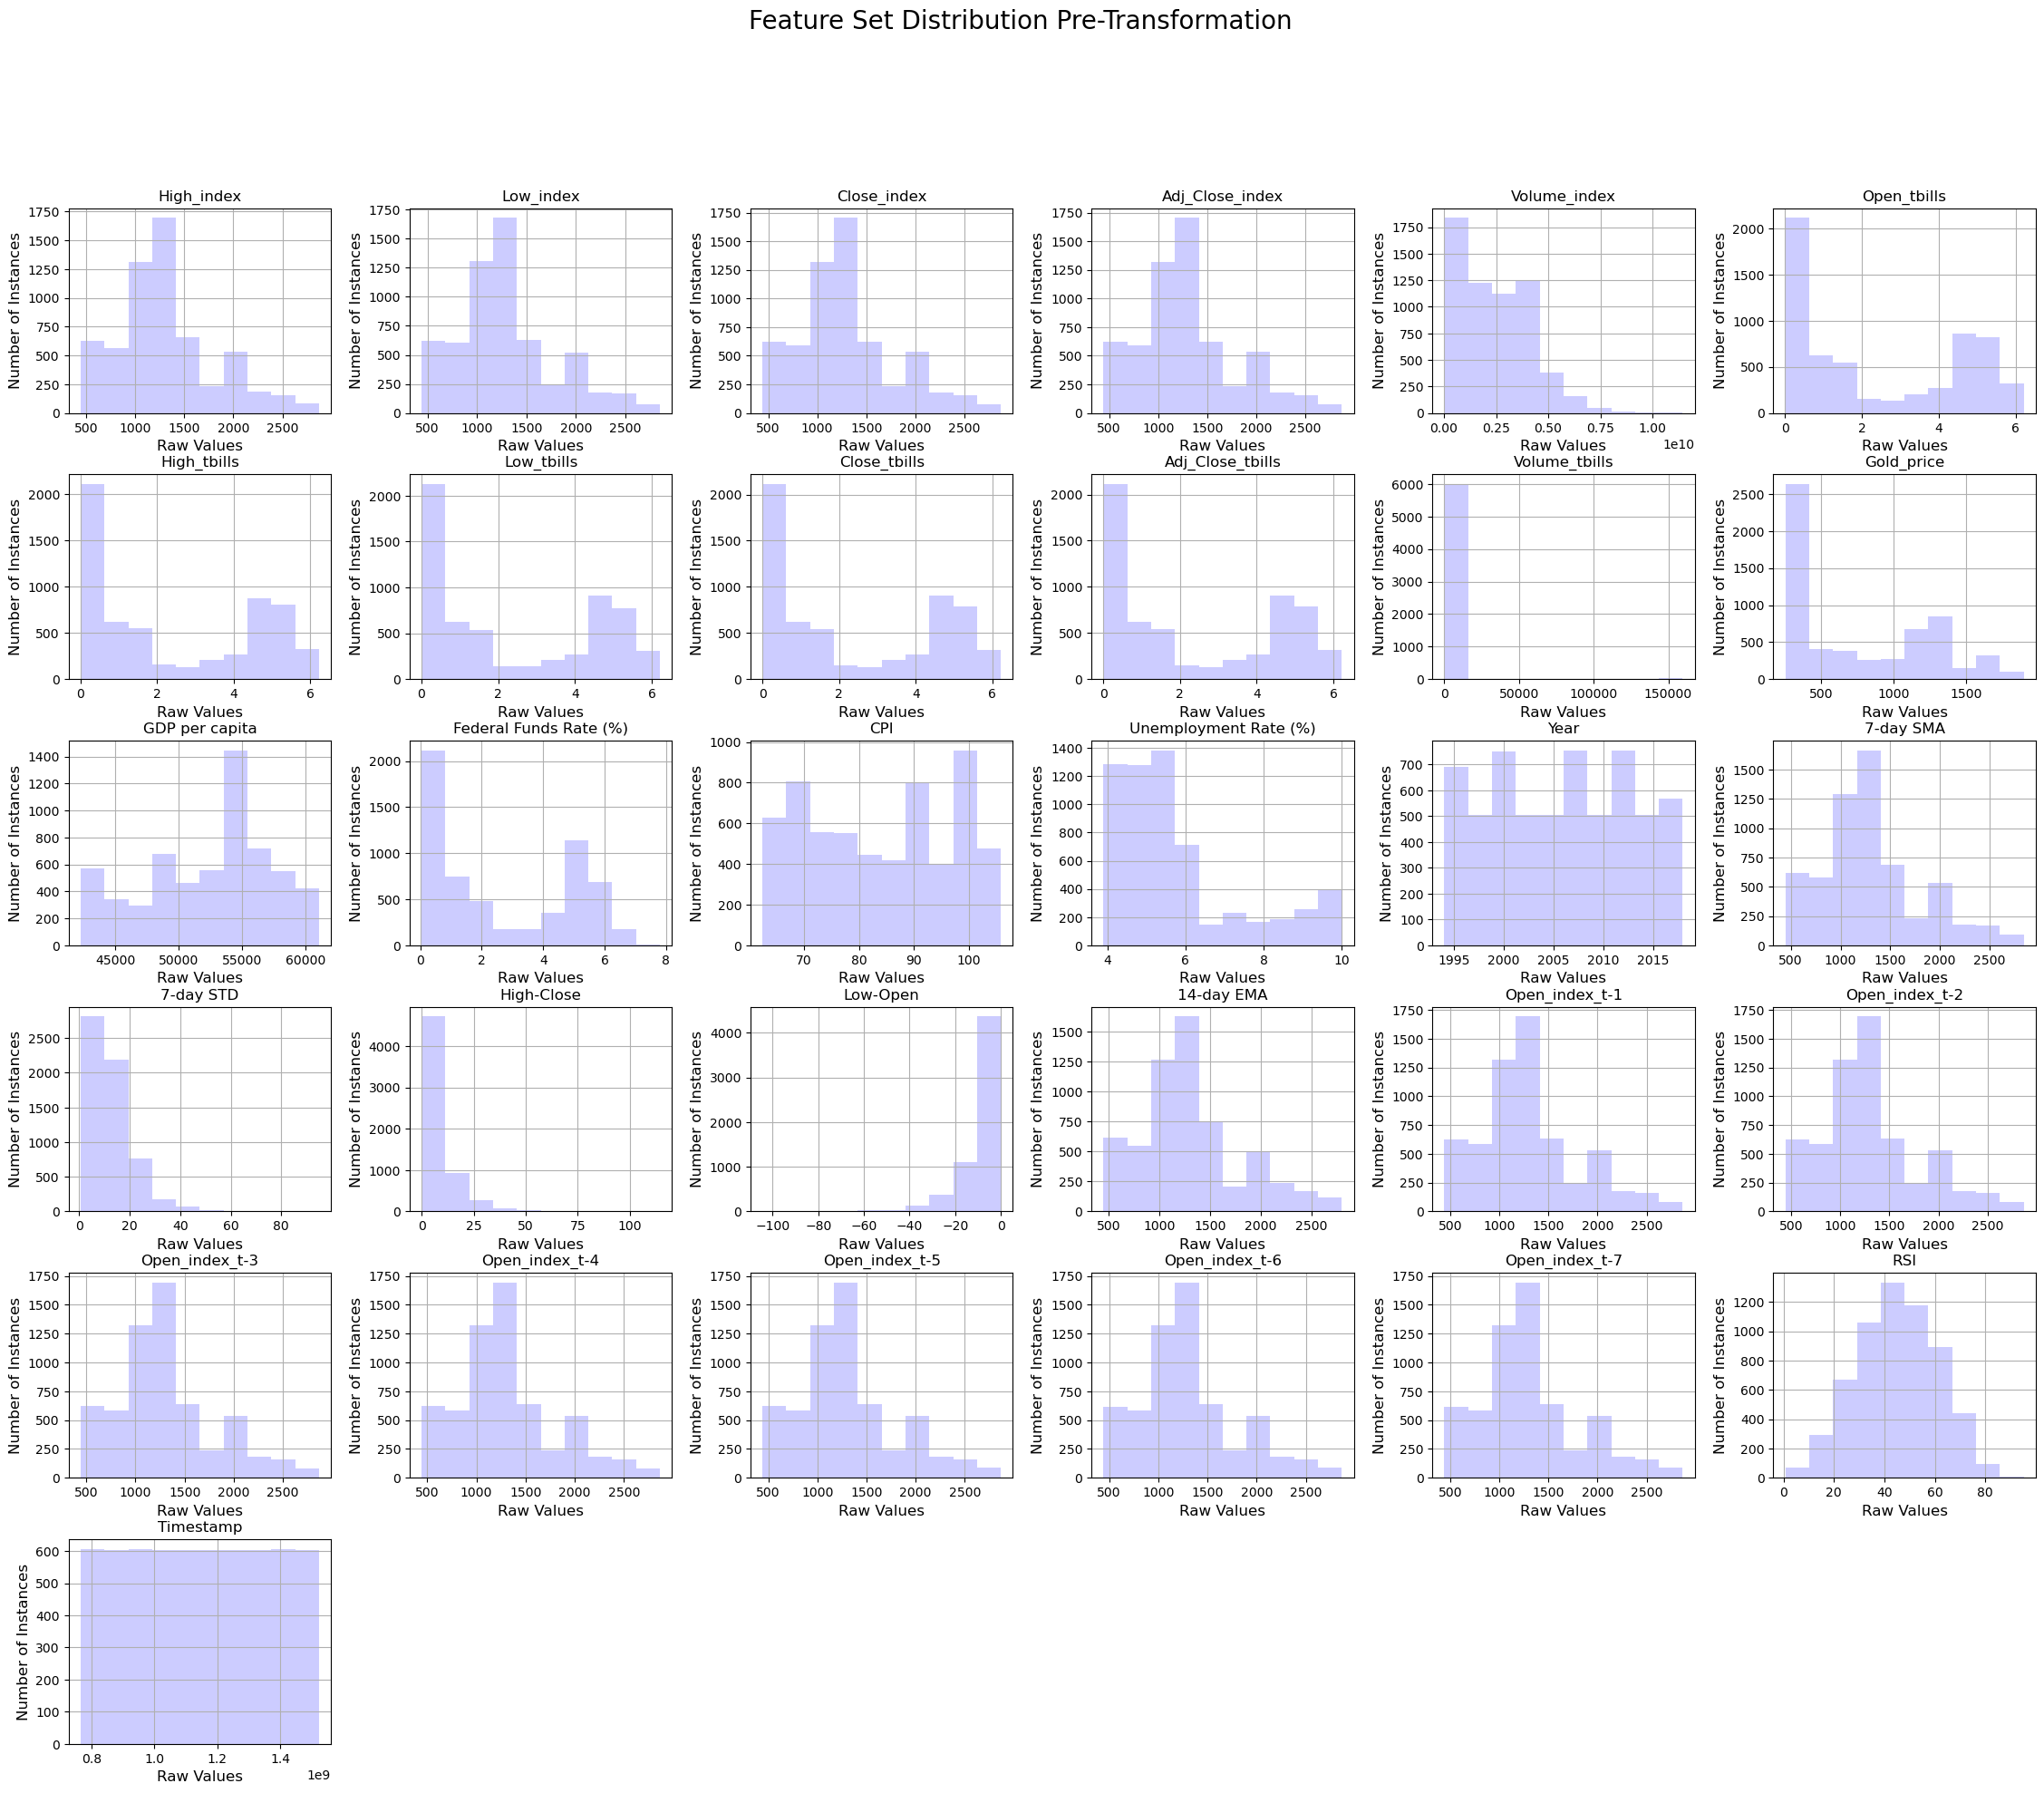

In [176]:
#Checking to see the distribution of feature set 
X_train.hist(figsize=(28, 22), color='blue', alpha=0.2)
plt.suptitle('Feature Set Distribution Pre-Transformation', fontsize=20)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Raw Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

In [177]:
X_train_copy = X_train.copy() #creating a copy of the training feature set

In [178]:
X_test_copy = X_test.copy() #creating a copy of the test feature set

We note that the features have different scales. We also observe that most features show a degree of skewness, with a majority showing a right-tail.  

In [179]:
#initialising a log transformer
log_transformer = FunctionTransformer(np.log1p, validate=False)

#Fitting and transforming columns in X_train_copy
log_X_train = log_transformer.fit_transform(X_train_copy[['High_index', 'Low_index', 'Close_index', 'Adj_Close_index', 'Volume_index', 'Open_tbills', 
              'High_tbills', 'Low_tbills', 'Close_tbills', 'Adj_Close_tbills', 'Volume_tbills','Gold_price',
              'GDP per capita', 'Federal Funds Rate (%)', 'CPI', 'Unemployment Rate (%)', '7-day SMA', '7-day STD', 
               'High-Close', '14-day EMA', 'Open_index_t-1', 'Open_index_t-2', 'Open_index_t-3', 'Open_index_t-4', 
                'Open_index_t-5',  'Open_index_t-6', 'Open_index_t-7']])

In [180]:
#Fitting and transforming columns in X_test_copy
log_X_test = log_transformer.transform(X_test_copy[['High_index', 'Low_index', 'Close_index', 'Adj_Close_index', 'Volume_index', 'Open_tbills', 
              'High_tbills', 'Low_tbills', 'Close_tbills', 'Adj_Close_tbills', 'Volume_tbills','Gold_price',
              'GDP per capita', 'Federal Funds Rate (%)', 'CPI', 'Unemployment Rate (%)', '7-day SMA', '7-day STD', 
               'High-Close', '14-day EMA', 'Open_index_t-1', 'Open_index_t-2', 'Open_index_t-3', 'Open_index_t-4', 
                'Open_index_t-5',  'Open_index_t-6', 'Open_index_t-7']])

In [181]:
#initialising a Standard scaler
standard_scaler = StandardScaler()

#fitting and transforming columns in X_train_copy 
normalized_log_X_train = standard_scaler.fit_transform(log_X_train)

In [183]:
#fitting and transforming columns in X_test_copy 
normalized_log_X_test = standard_scaler.transform(log_X_test)

In [184]:
normalized_log_X_train[-1] #code to check

array([ 1.98053084,  1.98573854,  1.98444143,  1.98444143,  0.67648484,
        0.01016469,  0.01292519,  0.01869842,  0.01902528,  0.01902528,
       -0.08662979,  1.1717541 ,  1.62272868, -0.05706191,  1.54370165,
       -1.32939366,  1.96970154,  0.86843895,  0.6752454 ,  1.98071615,
        1.96790257,  1.94008849,  1.96015663,  1.96506224,  1.9742098 ,
        1.99574145,  1.9889656 ])

In [185]:
#Copying list of columns transformed 
columns_transformed = ['High_index', 'Low_index', 'Close_index', 'Adj_Close_index', 'Volume_index', 'Open_tbills', 
              'High_tbills', 'Low_tbills', 'Close_tbills', 'Adj_Close_tbills', 'Volume_tbills','Gold_price',
              'Federal Funds Rate (%)', 'CPI', 'Unemployment Rate (%)', '7-day SMA', '7-day STD', 
               'High-Close', '14-day EMA', 'GDP per capita', 'Open_index_t-1', 'Open_index_t-2', 'Open_index_t-3', 'Open_index_t-4', 
                'Open_index_t-5',  'Open_index_t-6', 'Open_index_t-7']

#Creating a DataFrame with the transformed values
X_train_transformed = pd.DataFrame(
    normalized_log_X_train,
    columns=[f'{col}_log_scaled' for col in columns_transformed],
    index=X_train_copy.index
)

# Merge columns in original dataset with the newly transformed columns
X_train_scaled = pd.concat([X_train_copy[['Timestamp', 'Low-Open', 'RSI']], X_train_transformed], axis=1)

In [186]:
#Repeating concatenation for test data

#Creating a DataFrame with the transformed values
X_test_transformed = pd.DataFrame(
    normalized_log_X_test,
    columns=[f'{col}_log_scaled' for col in columns_transformed],
    index=X_test_copy.index
)

# Merge the Date column with the newly transformed columns
X_test_scaled = pd.concat([X_test_copy[['Timestamp', 'Low-Open', 'RSI']], X_test_transformed], axis=1)

<function matplotlib.pyplot.show(close=None, block=None)>

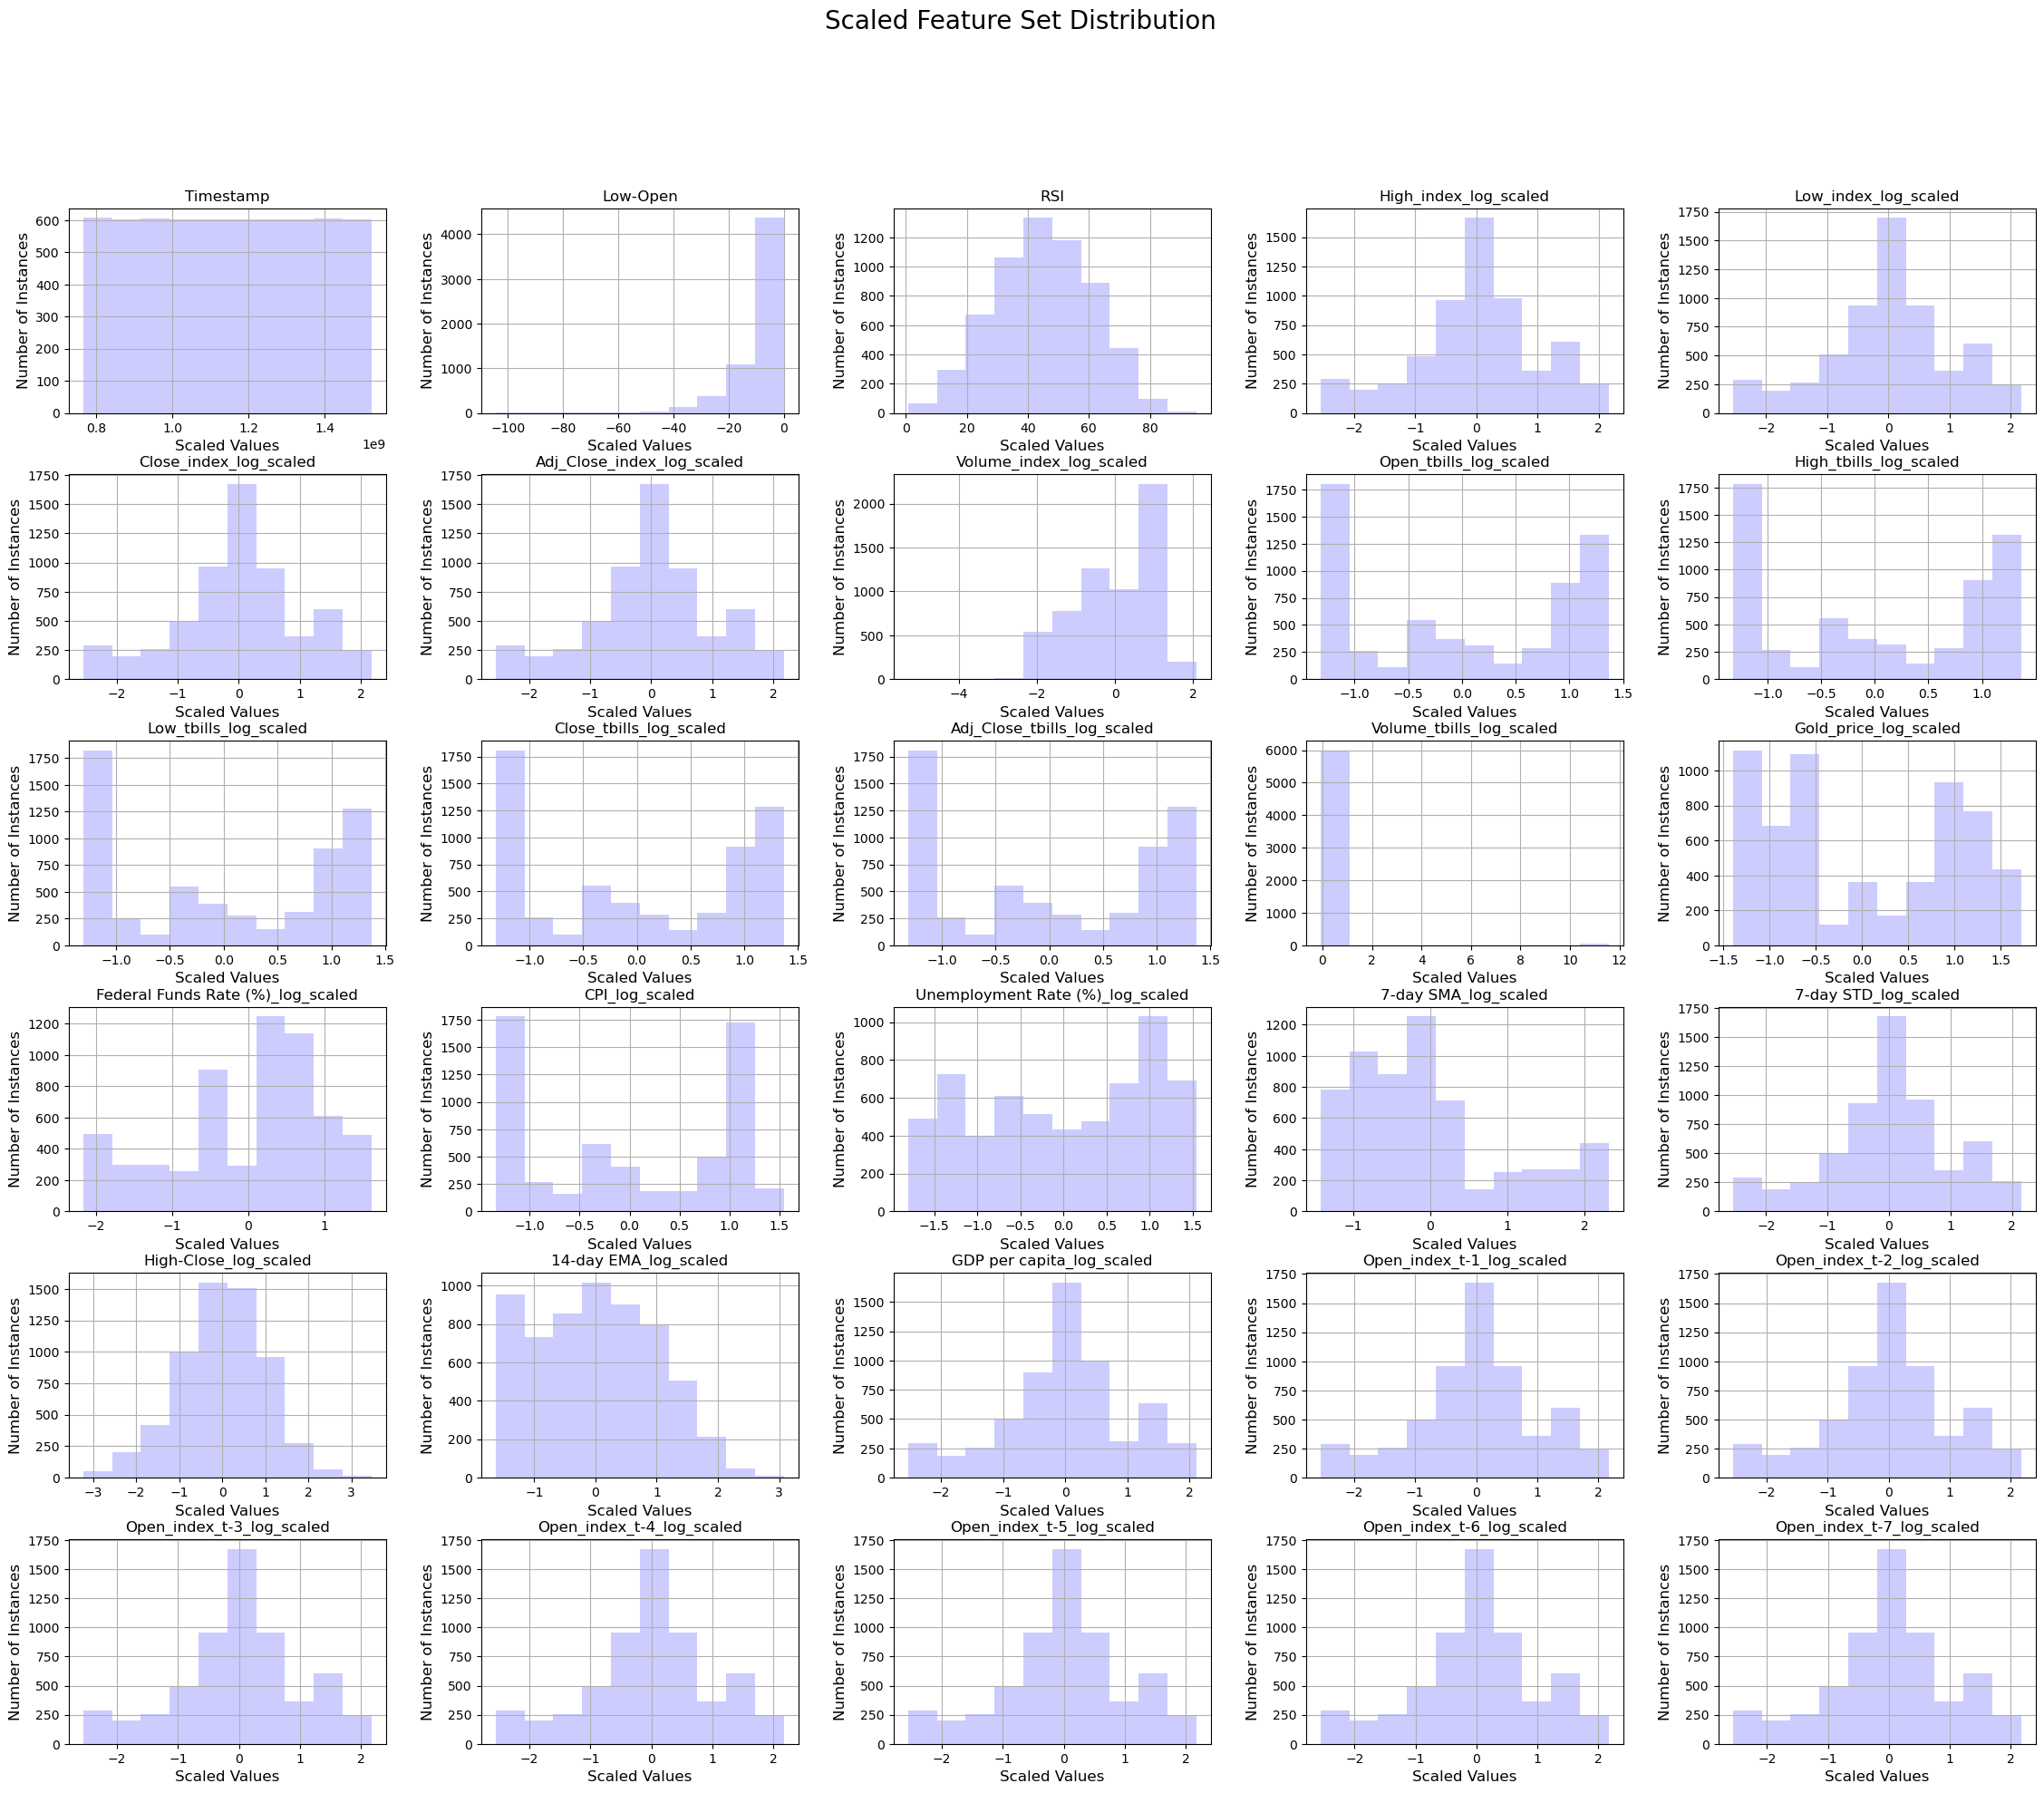

In [187]:
#Checking distribution of feature set post transformation
X_train_scaled.hist(figsize=(28, 22), color='blue', alpha=0.2)
plt.suptitle('Scaled Feature Set Distribution', fontsize=20)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Scaled Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

We see that the log and standardization transformers have been successful in transforming the distributions of some attributes but not others. We shall attempt other methods to bring about more normal distributions. 

In [189]:
#Performing Power Transformation 

#initialising the Power Transformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)


#Creating list of columns to be transformed further
pt_columns = ['Low-Open', 'Volume_index_log_scaled', 'Open_tbills_log_scaled',
              'High_tbills_log_scaled', 'Low_tbills_log_scaled', 'Close_tbills_log_scaled', 'Adj_Close_tbills_log_scaled',
              'Gold_price_log_scaled', 'Federal Funds Rate (%)_log_scaled', 'CPI_log_scaled', 'Unemployment Rate (%)_log_scaled',
              '7-day SMA_log_scaled', '14-day EMA_log_scaled']

#fitting and transforming columns within X_train_scaled
pt_array = pt.fit_transform(X_train_scaled[pt_columns])



# Create a DataFrame from the transformed values
pt_df = pd.DataFrame(pt_array, columns=[f'{col}_pt' for col in pt_columns], index=X_train_scaled.index)

<function matplotlib.pyplot.show(close=None, block=None)>

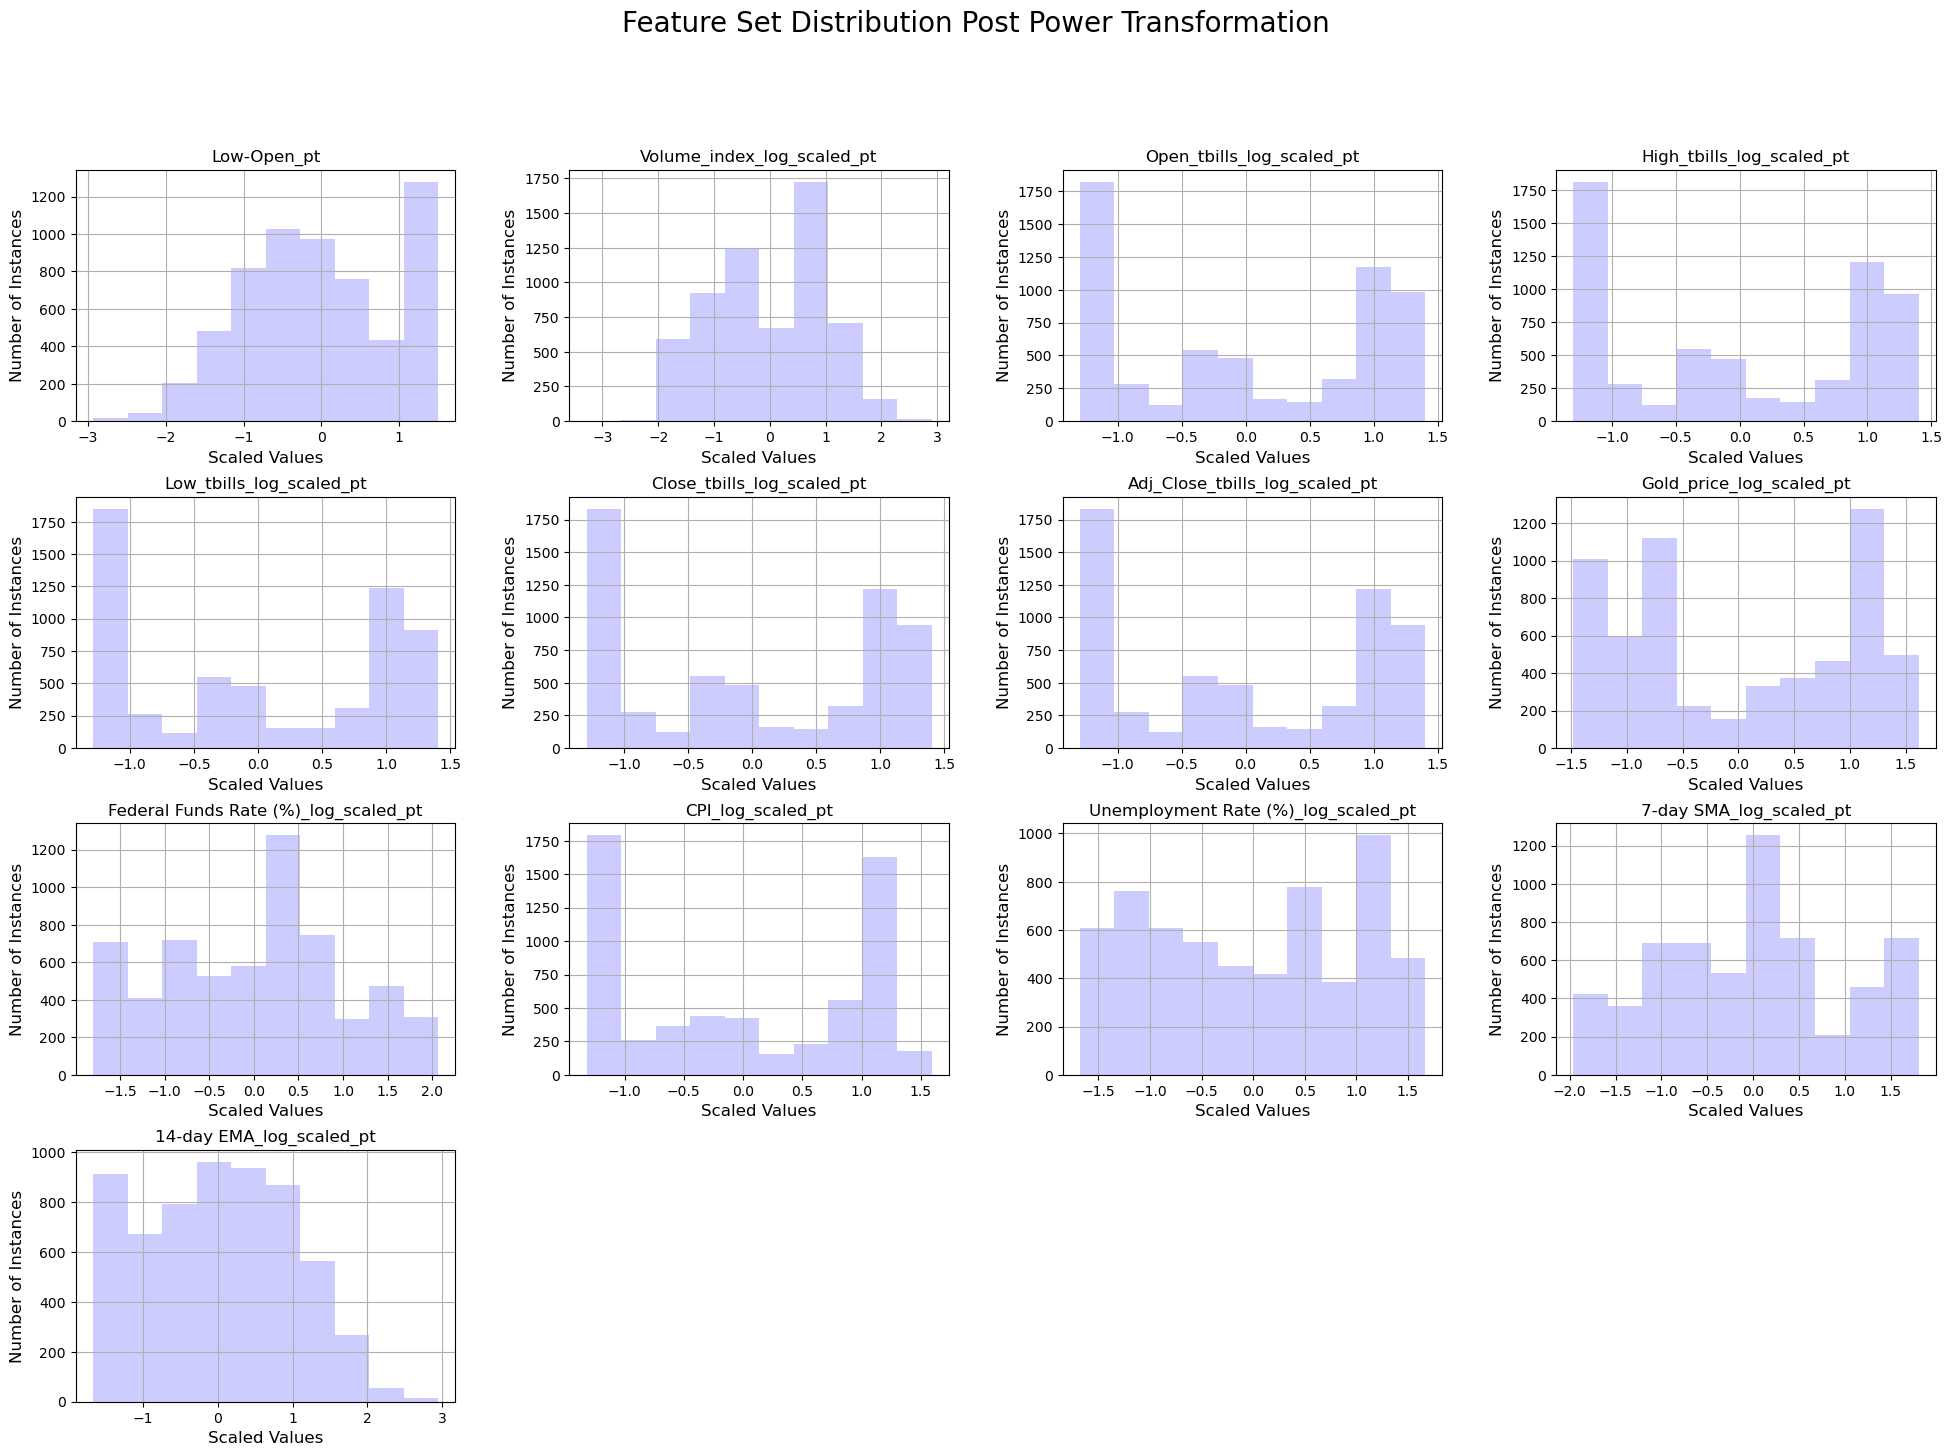

In [190]:
pt_df.hist(figsize=(24, 16), color='blue', alpha=0.2)
plt.suptitle('Feature Set Distribution Post Power Transformation', fontsize=20)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Scaled Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

In [191]:
#Repeating steps for test set

#fitting and transforming columns within X_test_scaled
pt_test_array = pt.transform(X_test_scaled[pt_columns])

# Create a DataFrame from the transformed values in the test set
pt_test_df = pd.DataFrame(pt_test_array, columns=[f'{col}_pt' for col in pt_columns], index=X_test_scaled.index)

We observe that the data that does not show near normal distribution is multimodal with multiple peaks. 

We will address this by bucketizing values.

In [192]:
#Performing quantile transformation for training set


qt_columns = ['Low-Open_pt', 'Volume_index_log_scaled_pt',
       'Open_tbills_log_scaled_pt', 'High_tbills_log_scaled_pt',
       'Low_tbills_log_scaled_pt', 'Close_tbills_log_scaled_pt',
       'Adj_Close_tbills_log_scaled_pt', 'Gold_price_log_scaled_pt',
       'Federal Funds Rate (%)_log_scaled_pt', 'CPI_log_scaled_pt',
       'Unemployment Rate (%)_log_scaled_pt', '7-day SMA_log_scaled_pt',
       '14-day EMA_log_scaled_pt']

qt = QuantileTransformer(output_distribution='normal')

#fitting and transforming the columns in the training set
pt_qt_array = qt.fit_transform(pt_df[qt_columns])

In [193]:
#Performing quantile transformation for test set

#fitting and transforming the columns in the test set
pt_qt_test_array = qt.transform(pt_test_df[qt_columns])

In [194]:
#Creating a DataFrame from the transformed values in the training set
qt_df = pd.DataFrame(pt_qt_array, columns=[f'{col}_qt' for col in qt_columns], index=pt_df.index)

In [195]:
#Creating a DataFrame from the transformed values in the test set
qt_test_df = pd.DataFrame(pt_qt_test_array, columns=[f'{col}_qt' for col in qt_columns], index=pt_test_df.index)

<function matplotlib.pyplot.show(close=None, block=None)>

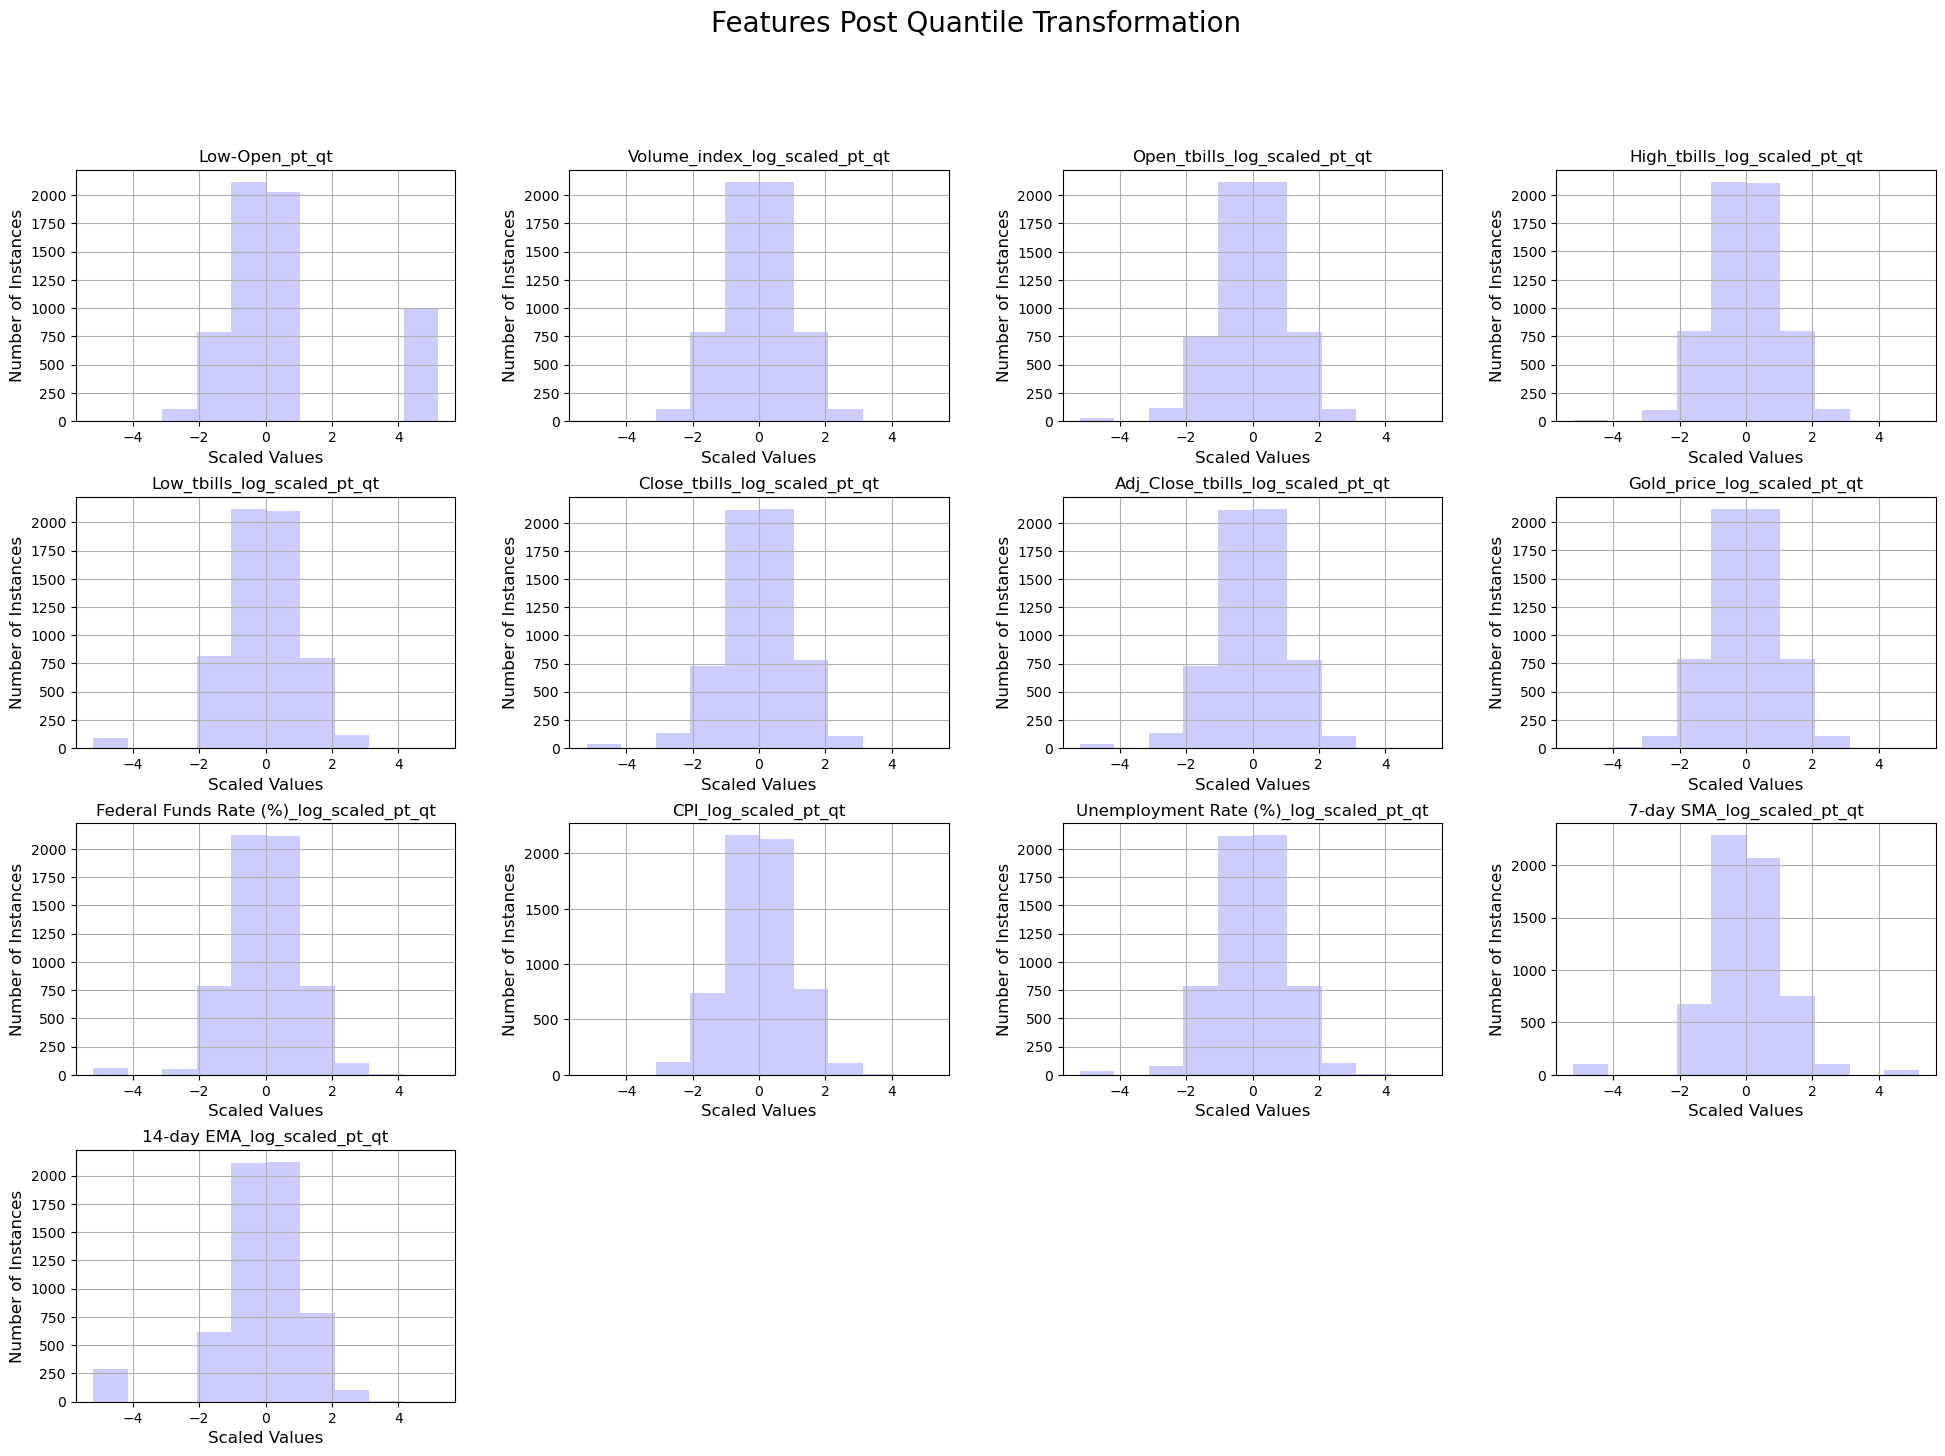

In [196]:
qt_df.hist(figsize=(24, 16), color='blue', alpha=0.2)
plt.suptitle('Features Post Quantile Transformation', fontsize=20)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Scaled Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

In [197]:
#Creating new dataframe with bucketized columns for training set
X_train_bucketized = pd.concat([X_train_scaled[['Timestamp', 'RSI', 'High_index_log_scaled', 'Low_index_log_scaled', 'Close_index_log_scaled', 'Adj_Close_index_log_scaled',
                                         'Volume_tbills_log_scaled', 'High-Close_log_scaled', 'GDP per capita_log_scaled', 'Open_index_t-1_log_scaled', 'Open_index_t-2_log_scaled', 'Open_index_t-3_log_scaled', 
                                        'Open_index_t-4_log_scaled', 'Open_index_t-5_log_scaled',  'Open_index_t-6_log_scaled', 'Open_index_t-7_log_scaled']], qt_df], axis=1)

In [198]:
#Creating new dataframe with bucketized columns for test set
X_test_bucketized = pd.concat([X_test_scaled[['Timestamp', 'RSI', 'High_index_log_scaled', 'Low_index_log_scaled', 'Close_index_log_scaled', 'Adj_Close_index_log_scaled',
                                         'Volume_tbills_log_scaled', 'High-Close_log_scaled', 'GDP per capita_log_scaled', 'Open_index_t-1_log_scaled', 'Open_index_t-2_log_scaled', 'Open_index_t-3_log_scaled', 
                                        'Open_index_t-4_log_scaled', 'Open_index_t-5_log_scaled',  'Open_index_t-6_log_scaled', 'Open_index_t-7_log_scaled']], qt_test_df], axis=1)

<function matplotlib.pyplot.show(close=None, block=None)>

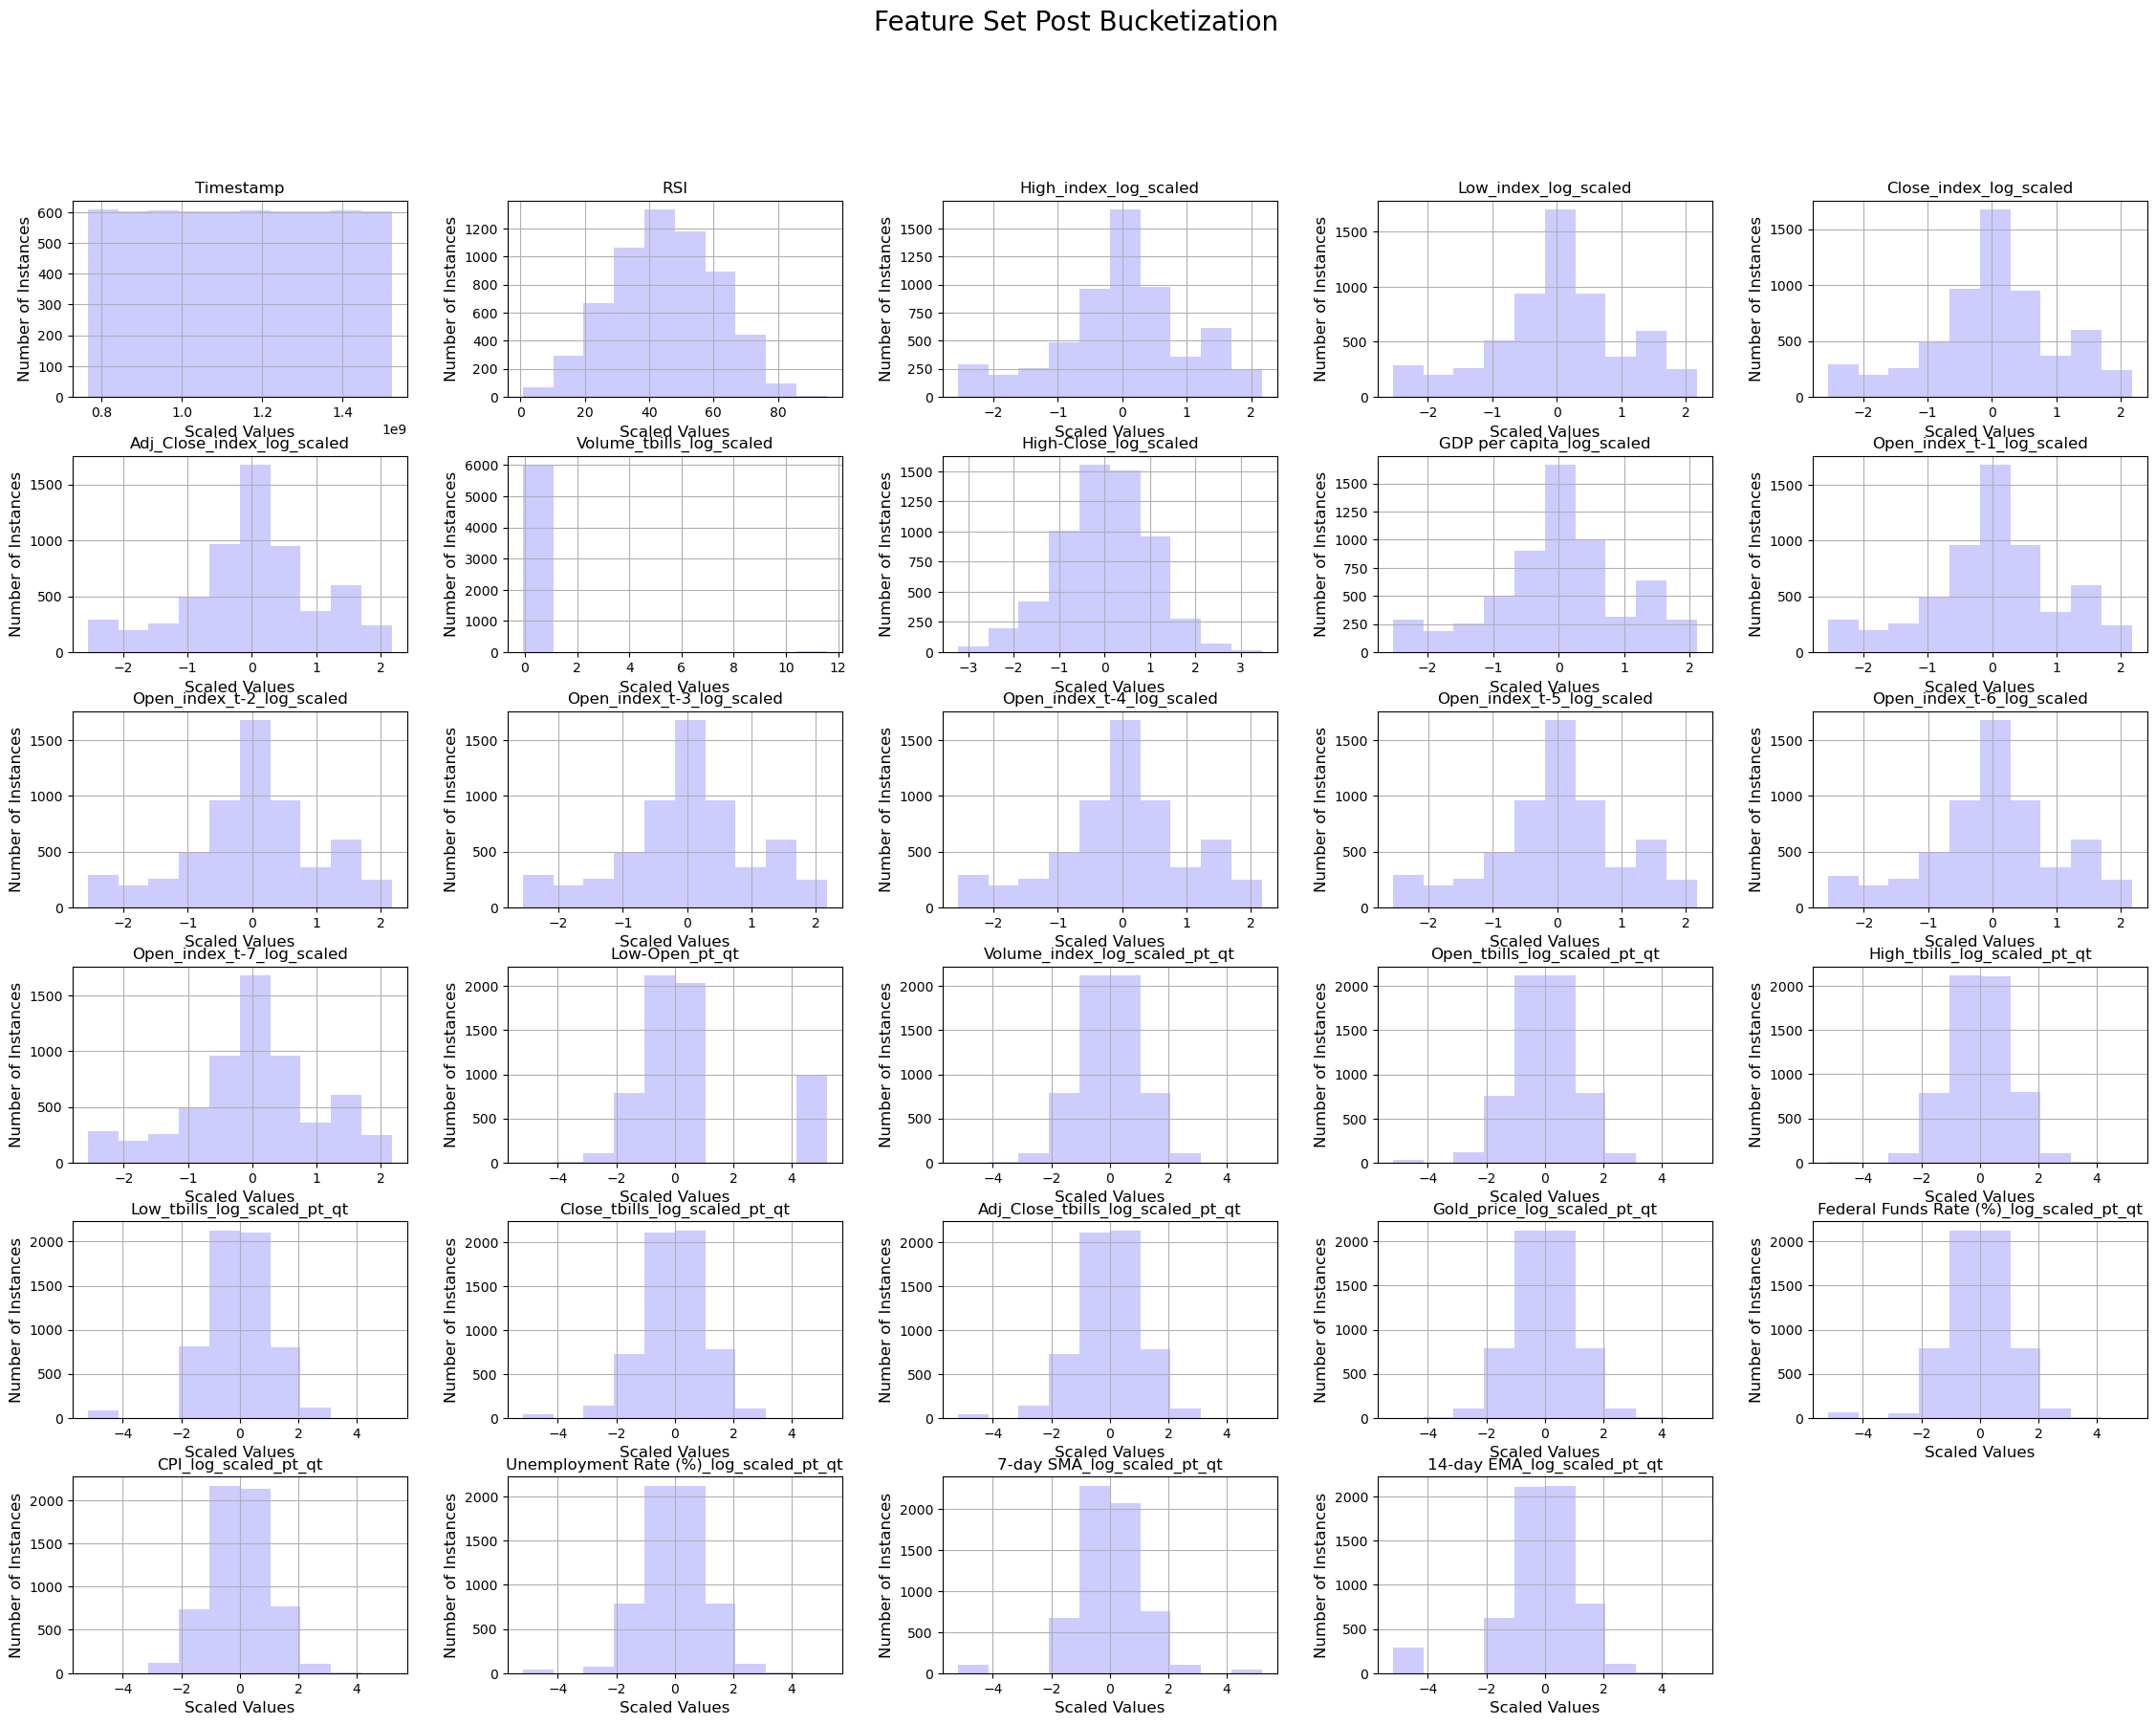

In [199]:
X_train_bucketized.hist(figsize=(28, 20), color='blue', alpha=0.2)
plt.suptitle('Feature Set Post Bucketization', fontsize=20)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Scaled Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

We have now brought a majority of the features to a near normal distribution and a similar scale in our training feature set, applying the same transformations to the test feature set. 

### Label Transformation <a class="anchor" id="label-transformation"></a>

<function matplotlib.pyplot.show(close=None, block=None)>

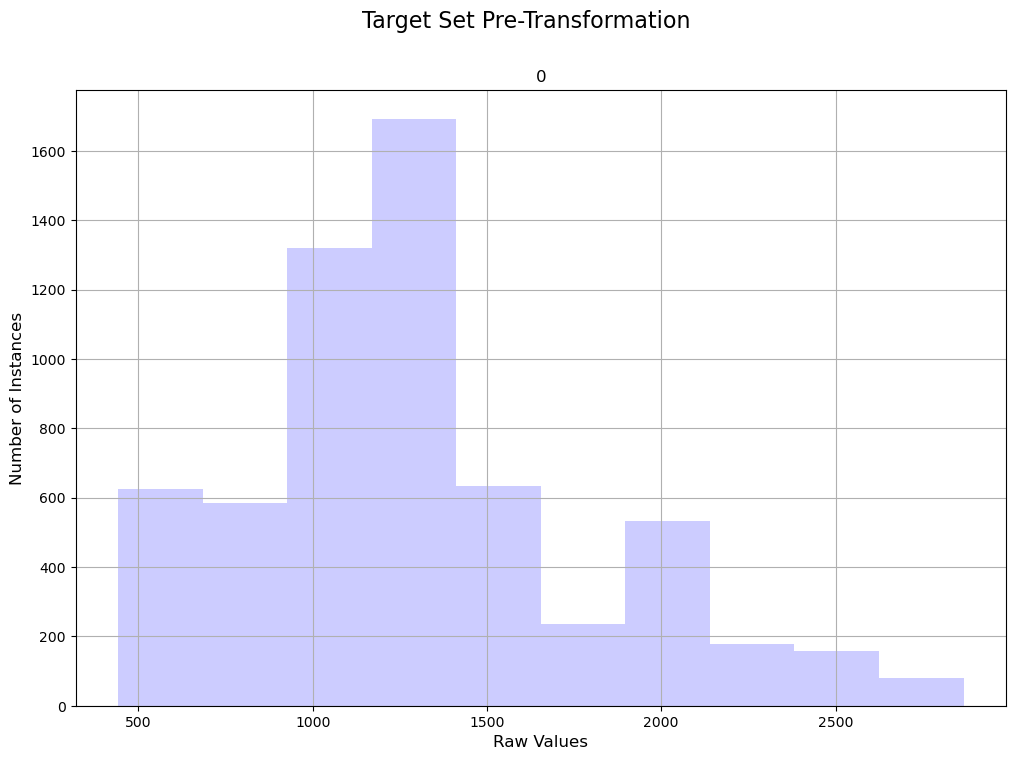

In [200]:
y_train.hist(figsize=(12, 8), color='blue', alpha=0.2)
plt.suptitle('Target Set Pre-Transformation', fontsize=16)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Raw Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

We observe that the data is skewed to the right which we may address through a log transformation. 

In [201]:
#Applying log transformation to y_train
y_train_copy = y_train.copy() #creating a copy of y train data

log_y_train = log_transformer.fit_transform(y_train) #fitting and transforming the log transformer on y train

#Applying same transformations to y_test 
y_test_copy = y_test.copy()

log_y_test = log_transformer.transform(y_test)# transforming the log transformer on y train

In [202]:
#Applying Standard Scaler to y_train and y_test
normalized_log_y_train = standard_scaler.fit_transform(log_y_train) #normalizing y train
normalized_log_y_test = standard_scaler.transform(log_y_test) #normalizing y train

In [203]:
normalized_log_y_train #code to check

array([[-2.49761171],
       [-2.51877727],
       [-2.50354487],
       ...,
       [ 1.91652081],
       [ 1.90858768],
       [ 1.97924727]])

In [204]:
#Creating a DataFrame with the transformed training values of the target variable 
y_train_scaled = pd.DataFrame(
    normalized_log_y_train,
    index=y_train_copy.index)

#Creating a DataFrame with the transformed test values of the target variable 
y_test_scaled = pd.DataFrame(
    normalized_log_y_test,
    index=y_test_copy.index)

<function matplotlib.pyplot.show(close=None, block=None)>

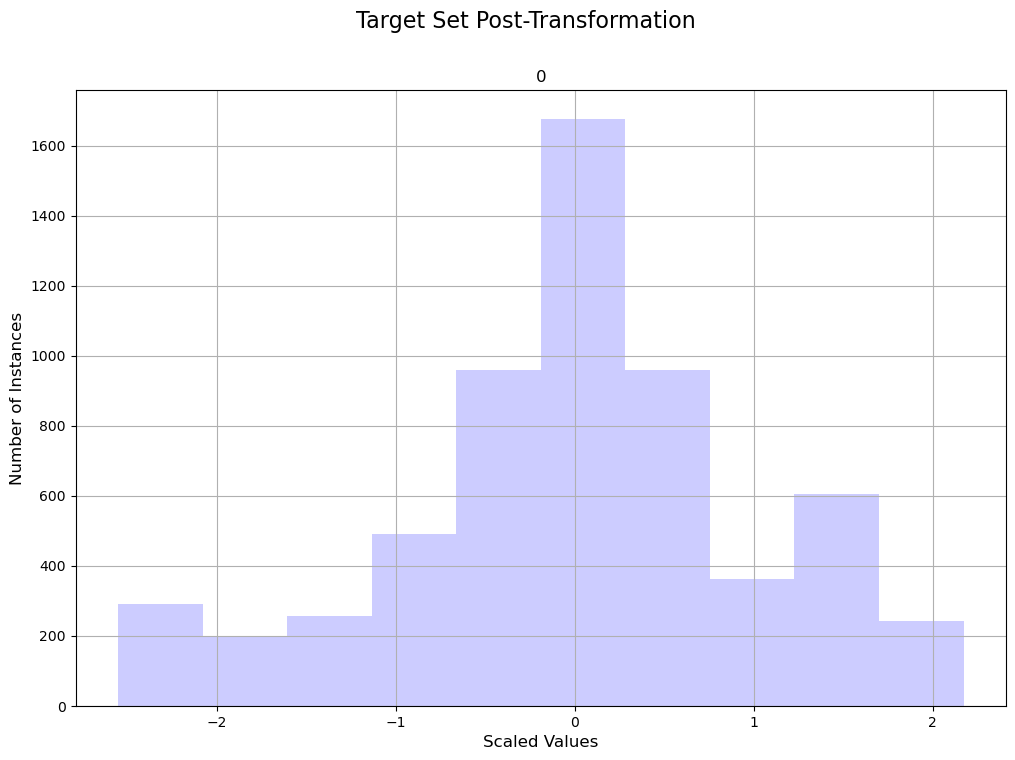

In [205]:
y_train_scaled.hist(figsize=(12, 8), color='blue', alpha=0.2)
plt.suptitle('Target Set Post-Transformation', fontsize=16)

for ax in plt.gcf().axes:  
    ax.set_xlabel('Scaled Values', fontsize=12)
    ax.set_ylabel('Number of Instances', fontsize=12)
plt.show

We have now brought a majority of the features to a near normal distribution and a similar scale in our training target set, applying the same transformations to the test target set. 

In [206]:
#Saving datasets for notebook transfer
X_train_bucketized.to_csv('X_train.csv', index=False)
y_train_scaled.to_csv('y_train.csv', index=False)
X_test_bucketized.to_csv('X_test.csv', index=False)
y_test_scaled.to_csv('y_test.csv', index=False)